# 10 — Role Deep Dives

Custom analysis for six high-interest job families: **Frontend Developer**, **Backend Developer**, **Fullstack Developer**, **Data Scientist**, **Data Engineer**, and **UI/UX Designer**.

Covers cross-role comparison radar, skill profiles & transferability, seniority-based skill progression, salary analysis (with sample-size caveats), demographics, and benefits/soft skills.

> **Sample-size note:** Salary data is sparse — only ~7% of postings include salary ranges. Per-role salary analyses (especially Data Scientist n=5, Data Engineer n=5, UI/UX Designer n=0) should be interpreted directionally, not as reliable estimates.

In [1]:
from analysis.utils import notebook_init
from analysis.filters import (
    exclude_future_dates, exclude_other_family,
    salary_df, explode_json_col, filter_by_job_family,
)
from analysis.compute import (
    skill_counts, skill_cooccurrence, required_vs_optional_skills,
    skill_salary_premium, skill_progression, skill_overlap_matrix,
    categorical_distribution, language_requirement_pct,
)
from analysis import charts as _charts
from analysis.charts import horizontal_bar, heatmap, value_bar, stacked_bar, box_plot, radar_chart

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from shared.json_utils import parse_json_list

df_raw = notebook_init()
df = exclude_future_dates(df_raw)
df = exclude_other_family(df)
print(f"After filtering: {len(df):,} rows (removed {len(df_raw) - len(df):,} future-dated + Other)")

Loaded 18,949 rows × 25 columns
After filtering: 18,014 rows (removed 935 future-dated + Other)


In [2]:
TARGET_ROLES = [
    "Frontend Developer",
    "Backend Developer",
    "Fullstack Developer",
    "Data Scientist",
    "Data Engineer",
    "UI/UX Designer",
]

roles = {name: filter_by_job_family(df, name) for name in TARGET_ROLES}

# Pre-compute salary subsets (reused across multiple sections)
salary_by_role = {name: salary_df(rdf) for name, rdf in roles.items()}

for name, rdf in roles.items():
    sn = len(salary_by_role[name])
    print(f"{name}: {len(rdf):,} postings  (salary known: {sn})")

Frontend Developer: 461 postings  (salary known: 18)
Backend Developer: 795 postings  (salary known: 26)
Fullstack Developer: 1,529 postings  (salary known: 72)
Data Scientist: 344 postings  (salary known: 5)
Data Engineer: 776 postings  (salary known: 5)
UI/UX Designer: 99 postings  (salary known: 0)


## Overview Comparison

Summary snapshot across key dimensions. See "Salary rows" column for sample sizes — interpret salary figures cautiously for roles with fewer than 15 rows.

In [3]:
summary_rows = []
for name, rdf in roles.items():
    sdf = salary_by_role[name]
    german_pct = rdf["languages"].apply(
        lambda x: "german" in str(x).lower() if pd.notna(x) else False
    ).mean() * 100 if len(rdf) else 0.0
    exp = pd.to_numeric(rdf["experience_years"], errors="coerce").dropna()

    summary_rows.append({
        "Role": name,
        "Count": len(rdf),
        "% of market": f"{len(rdf)/len(df)*100:.1f}%",
        "Top city": rdf["city"].value_counts().index[0] if len(rdf) and rdf["city"].notna().any() else "N/A",
        "Remote %": f"{(rdf['work_modality'] == 'Remote').mean()*100:.0f}%" if len(rdf) else "N/A",
        "Median salary": f"€{int(sdf['salary_mid'].median()):,}" if len(sdf) else "N/A",
        "Salary rows": len(sdf),
        "Median exp (yr)": f"{exp.median():.0f}" if len(exp) else "N/A",
        "German req %": f"{german_pct:.0f}%",
    })

overview = pd.DataFrame(summary_rows).set_index("Role")
overview

,Count,% of market,Top city,Remote %,Median salary,Salary rows,Median exp (yr),German req %
Role,,,,,,,,
Frontend Developer,461,2.6%,Berlin,30%,"€58,750",18,3,37%
Backend Developer,795,4.4%,Berlin,32%,"€76,750",26,3,28%
Fullstack Developer,1529,8.5%,Berlin,31%,"€68,750",72,3,37%
Data Scientist,344,1.9%,Berlin,17%,"€75,000",5,3,25%
Data Engineer,776,4.3%,Berlin,21%,"€83,000",5,3,37%
UI/UX Designer,99,0.5%,Berlin,62%,N/A,0,3,6%


## Role Comparison Radar

Multi-dimensional comparison across normalised axes (0–100 scale). Each axis is min-max normalised across the six roles, so the chart shows *relative* positioning, not absolute values.

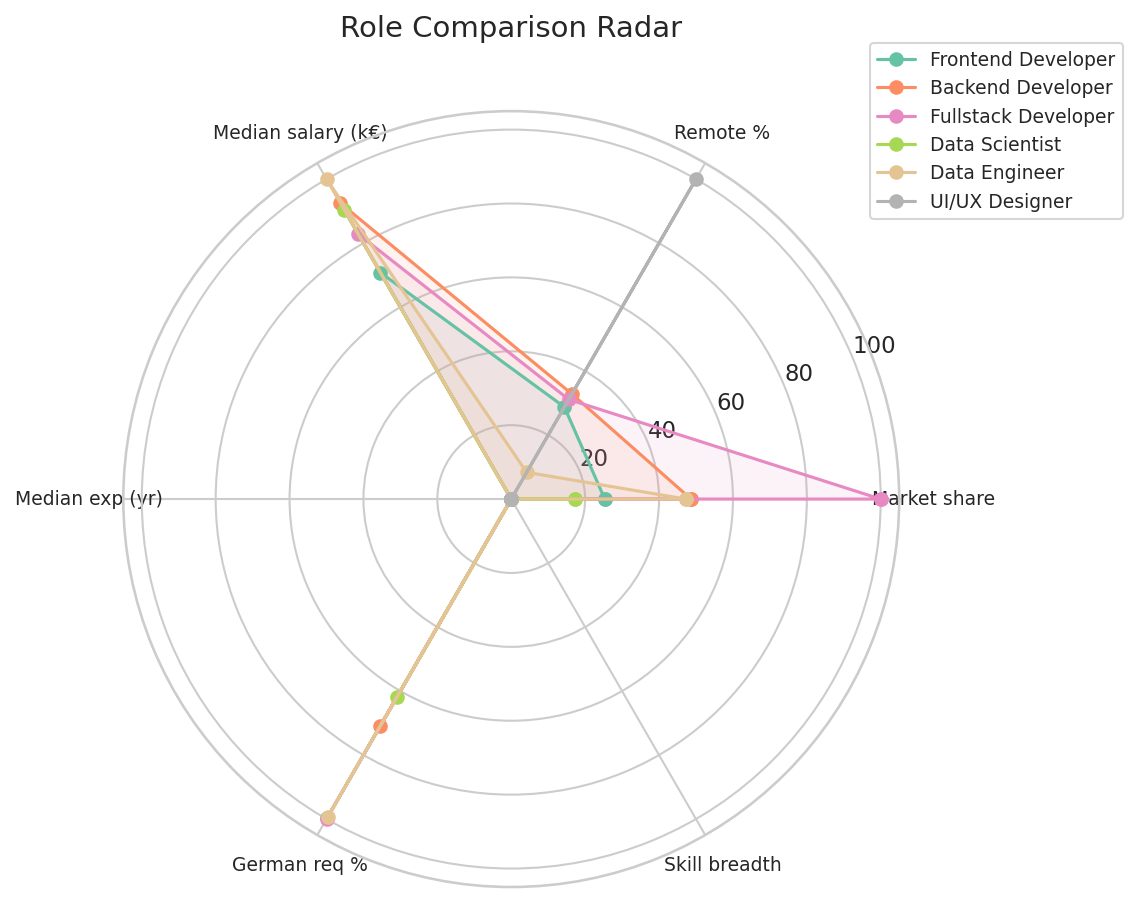

Raw values (before normalisation):


,Market share,Remote %,Median salary (k€),Median exp (yr),German req %,Skill breadth
Role,,,,,,
Frontend Developer,2.6,30.2,58.8,3.0,37.1,30
Backend Developer,4.4,31.9,76.8,3.0,28.2,30
Fullstack Developer,8.5,31.2,68.8,3.0,37.2,30
Data Scientist,1.9,17.4,75.0,3.0,25.3,30
Data Engineer,4.3,21.1,83.0,3.0,37.0,30
UI/UX Designer,0.5,61.6,0.0,3.0,6.1,30


In [4]:
radar_rows = []
for name, rdf in roles.items():
    sdf = salary_by_role[name]
    exp = pd.to_numeric(rdf["experience_years"], errors="coerce").dropna()
    german_pct = rdf["languages"].apply(
        lambda x: "german" in str(x).lower() if pd.notna(x) else False
    ).mean() * 100 if len(rdf) else 0.0
    n_unique_skills = len(skill_counts(rdf, top_n=30))

    radar_rows.append({
        "Role": name,
        "Market share": len(rdf) / len(df) * 100,
        "Remote %": (rdf["work_modality"] == "Remote").mean() * 100 if len(rdf) else 0,
        "Median salary (k€)": sdf["salary_mid"].median() / 1000 if len(sdf) else 0,
        "Median exp (yr)": exp.median() if len(exp) else 0,
        "German req %": german_pct,
        "Skill breadth": n_unique_skills,
    })

radar_df = pd.DataFrame(radar_rows).set_index("Role")

# Normalise each column to 0-100 for visual comparability
radar_norm = radar_df.apply(lambda c: (c - c.min()) / max(c.max() - c.min(), 1) * 100)

radar_chart(radar_norm, "Role Comparison Radar", save_as="10_role_radar.png")

print("Raw values (before normalisation):")
radar_df.round(1)

**Takeaway:** Fullstack Developer dominates market share and shows the broadest skill profile. UI/UX Designer stands out with the highest remote rate but smallest market presence. Data Engineer commands the highest median salary, while Frontend and Fullstack roles have the strongest German language requirements.

## Top Technical Skills by Role

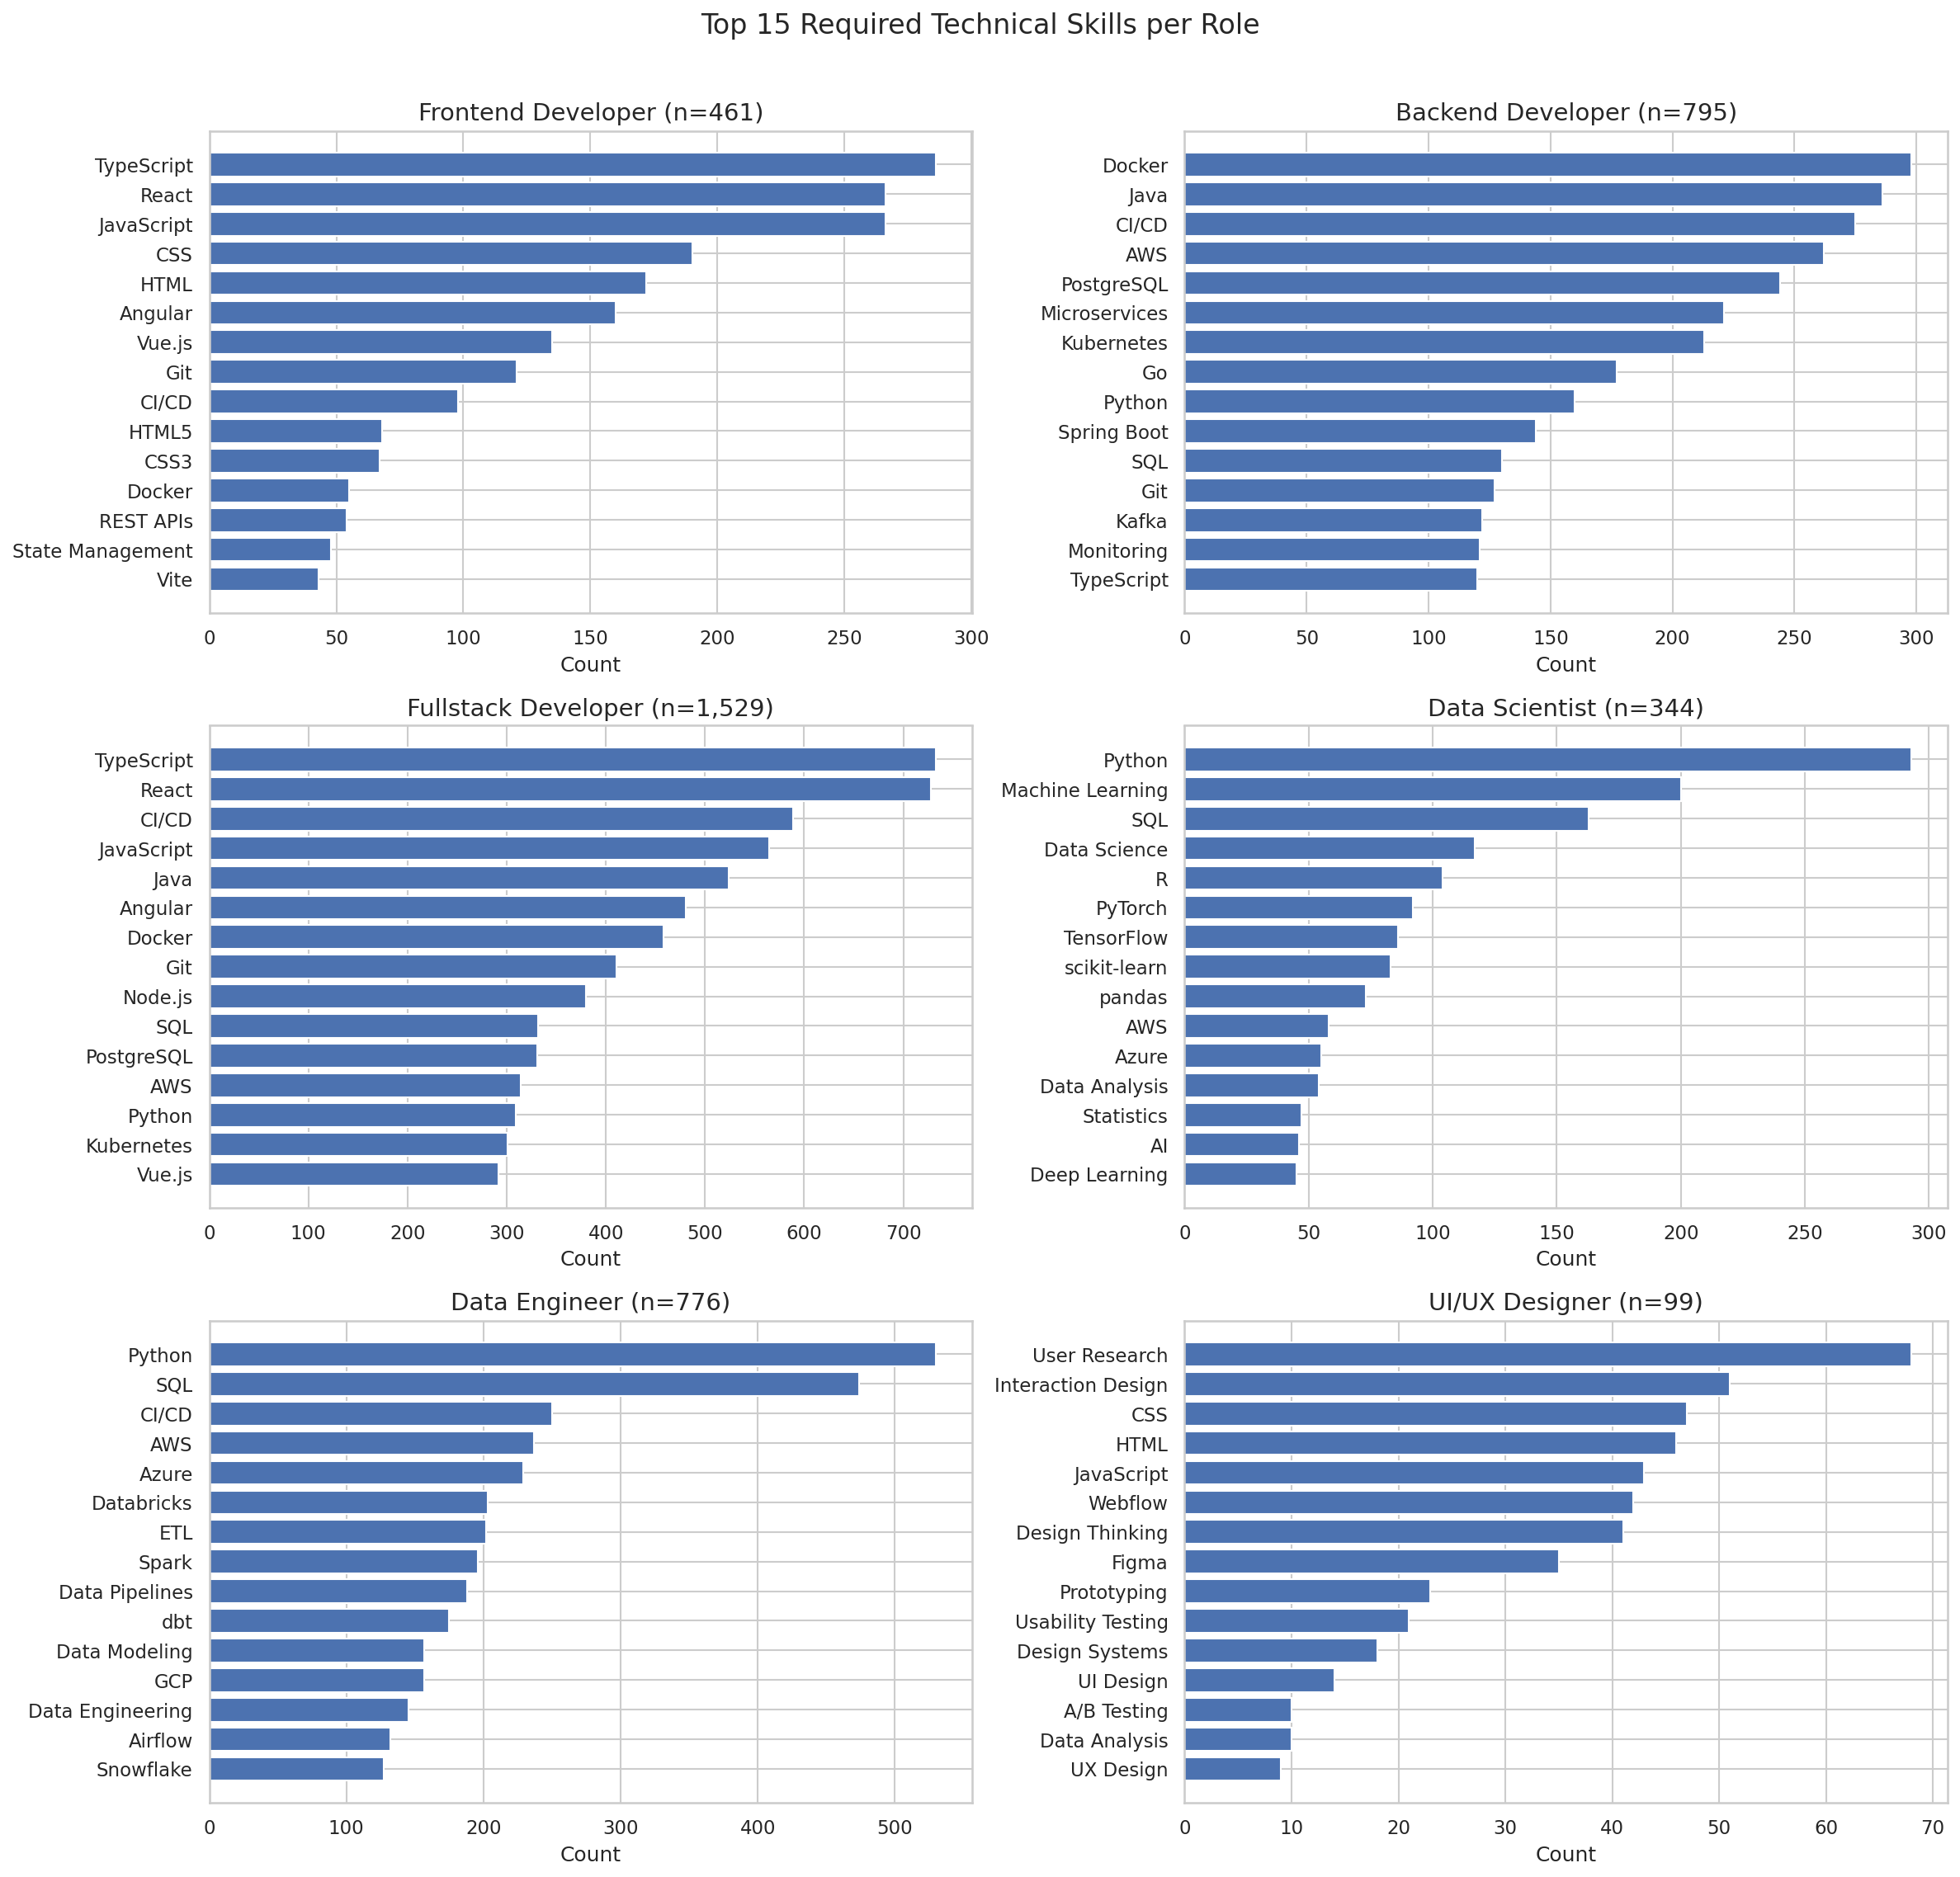

In [5]:
n_roles = len(TARGET_ROLES)
cols = 2
rows_grid = int(np.ceil(n_roles / cols))

fig, axes = plt.subplots(rows_grid, cols, figsize=(16, 5 * rows_grid))
fig.suptitle("Top 15 Required Technical Skills per Role", fontsize=16, y=1.01)

for ax, name in zip(axes.flat, TARGET_ROLES):
    rdf = roles[name]
    top = skill_counts(rdf, "technical_skills", top_n=15).sort_values()
    ax.barh(top.index, top.values)
    ax.set_title(f"{name} (n={len(rdf):,})")
    ax.set_xlabel("Count")

for ax in axes.flat[n_roles:]:
    ax.set_visible(False)

plt.tight_layout()
if _charts.FIGURES_DIR:
    fig.savefig(_charts.FIGURES_DIR / "10_skills_by_role.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

**Takeaway:** TypeScript/React dominate frontend and fullstack roles, while Python is king for data roles. Backend development shows the most diverse language ecosystem (Docker, Java, CI/CD, AWS, Go). UI/UX Designer uniquely prioritises User Research and Interaction Design as top "technical" skills — a fundamentally different profile from engineering roles.

## Required vs Nice-to-Have Skills

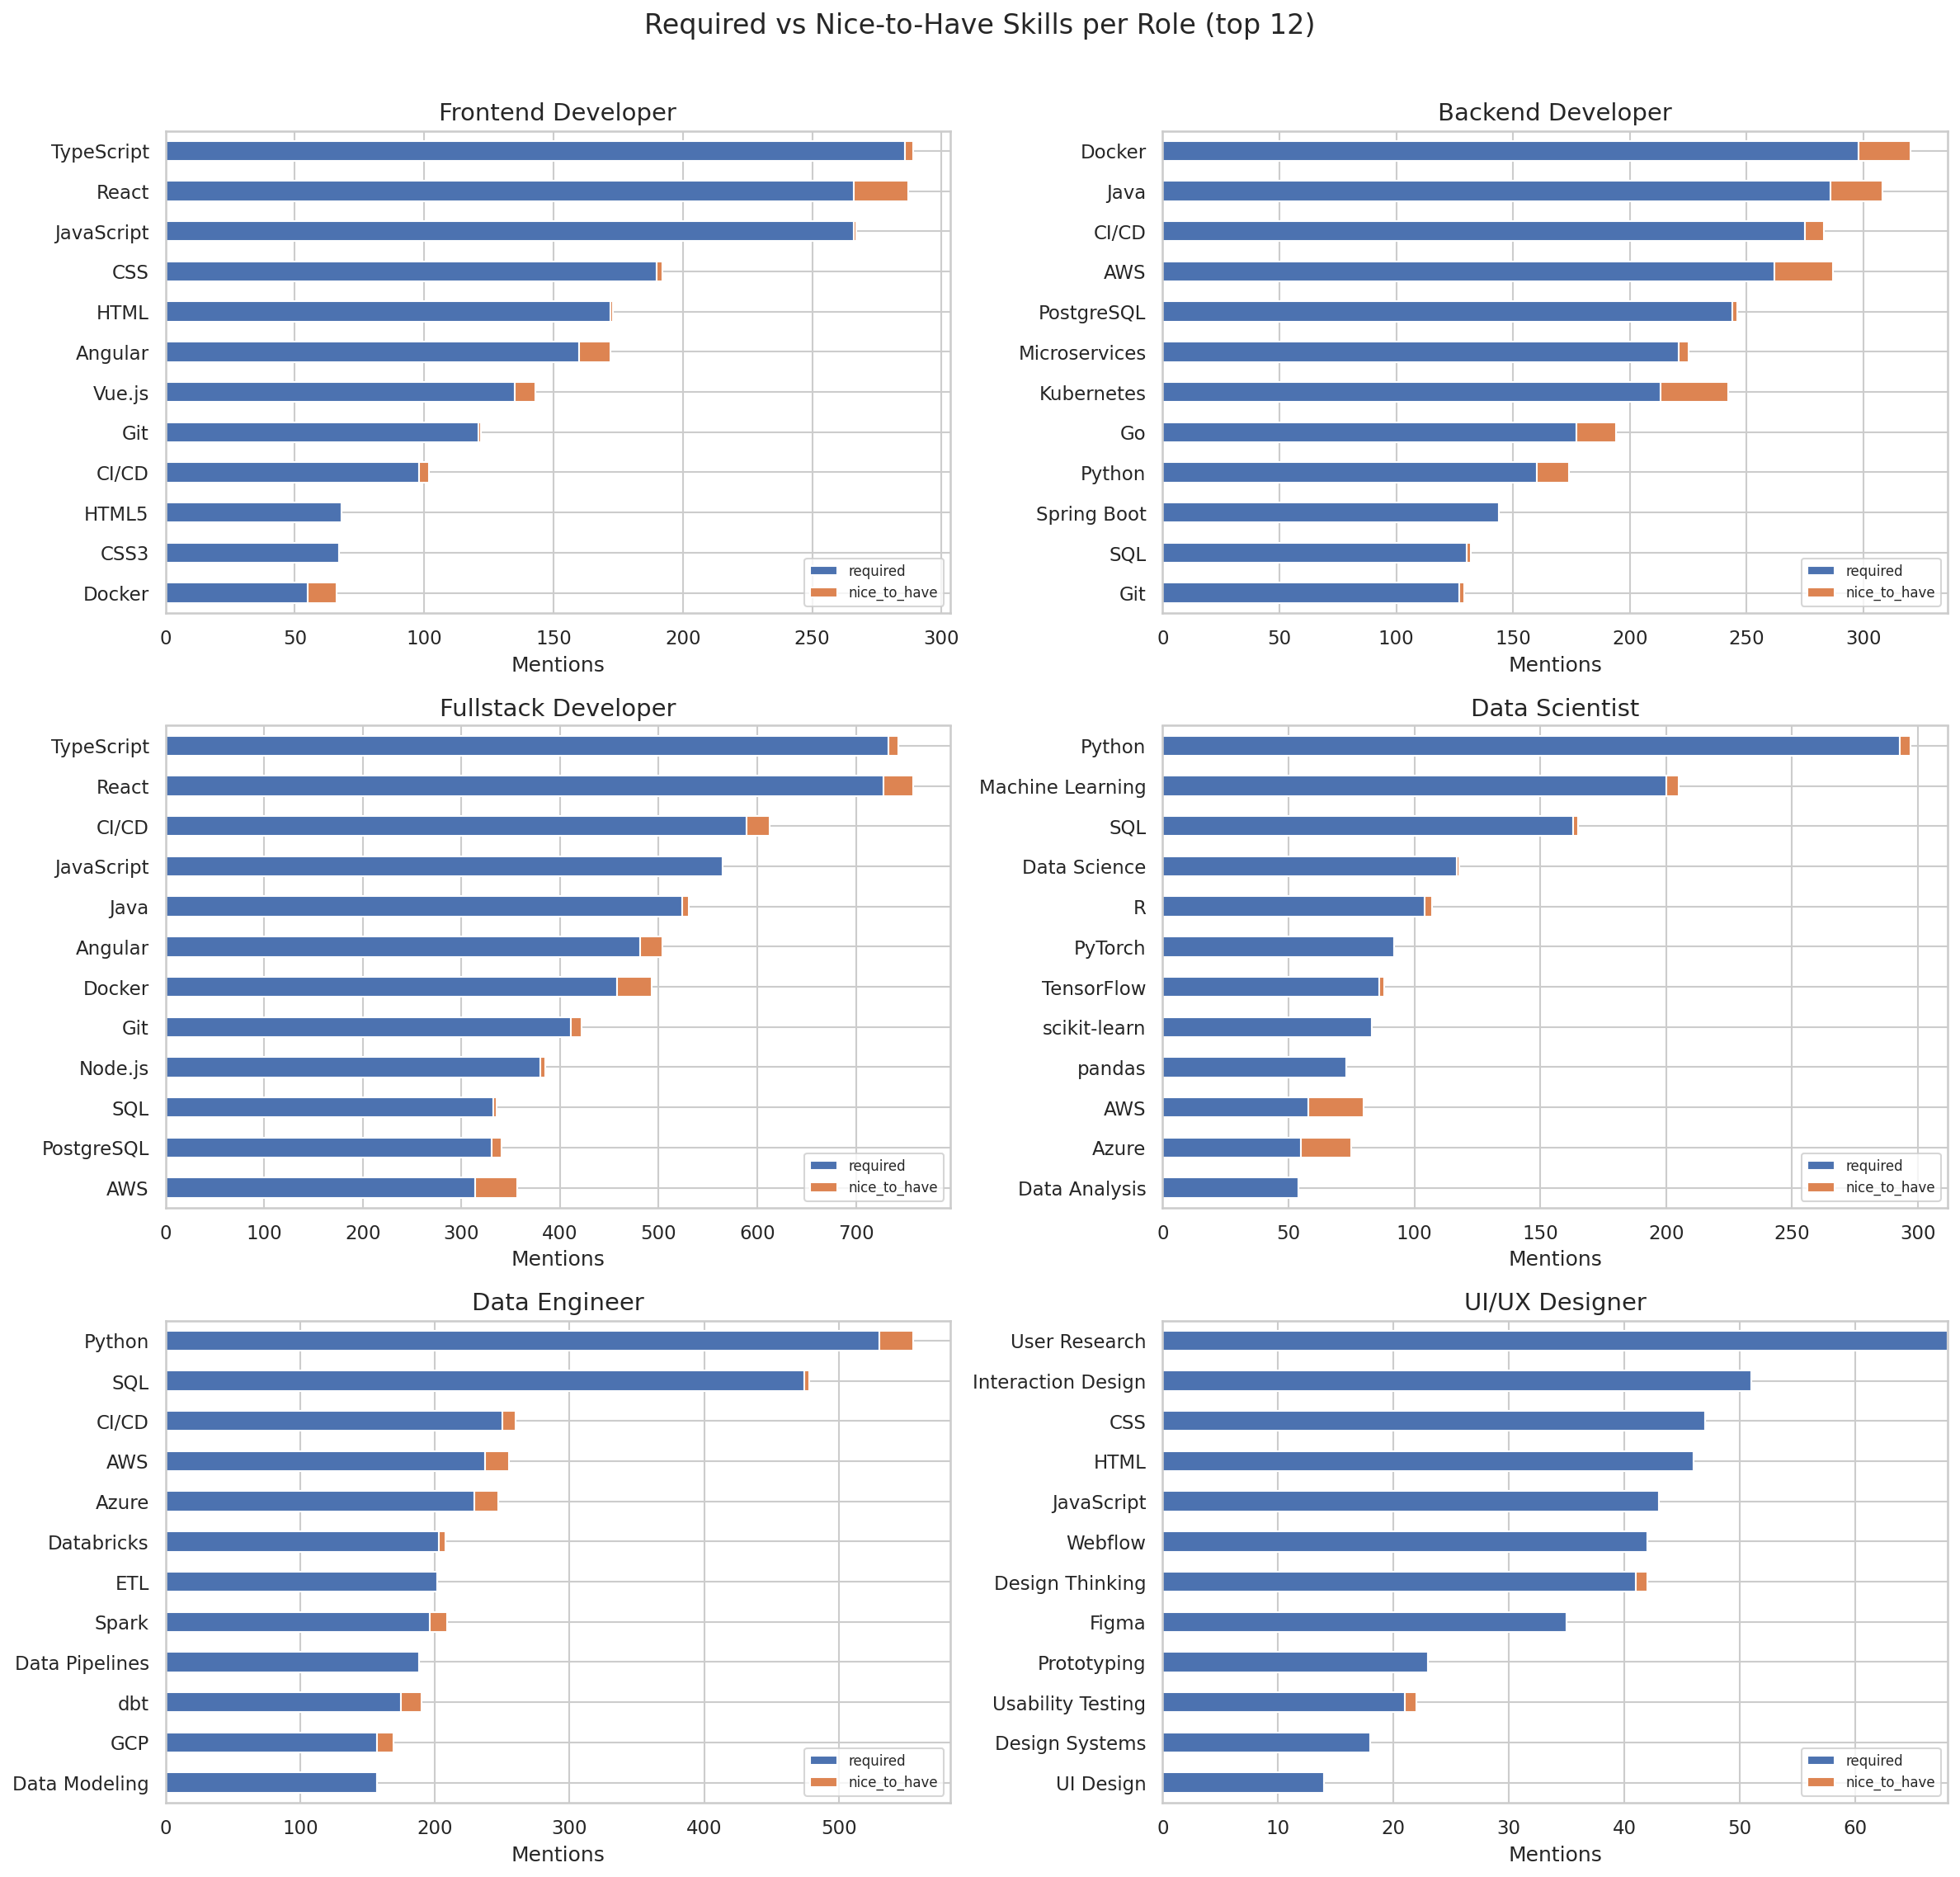

In [6]:
fig, axes = plt.subplots(rows_grid, cols, figsize=(16, 5 * rows_grid))
fig.suptitle("Required vs Nice-to-Have Skills per Role (top 12)", fontsize=16, y=1.01)

for ax, name in zip(axes.flat, TARGET_ROLES):
    rdf = roles[name]
    rvo = required_vs_optional_skills(rdf, top_n=12)
    rvo[["required", "nice_to_have"]].sort_values("required").plot.barh(
        stacked=True, ax=ax, color=["#4C72B0", "#DD8452"]
    )
    ax.set_title(f"{name}")
    ax.set_xlabel("Mentions")
    ax.legend(fontsize=8)

for ax in axes.flat[n_roles:]:
    ax.set_visible(False)

plt.tight_layout()
if _charts.FIGURES_DIR:
    fig.savefig(_charts.FIGURES_DIR / "10_req_vs_nth_by_role.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

**Takeaway:** Most top skills are overwhelmingly "required" rather than "nice-to-have" across all roles. The nice-to-have fringe is largest in Backend (Go, TypeScript) and Data Engineer (Databricks, Spark) — these represent emerging or supplementary skills where employers are more flexible.

## Skill Co-occurrence (per role)

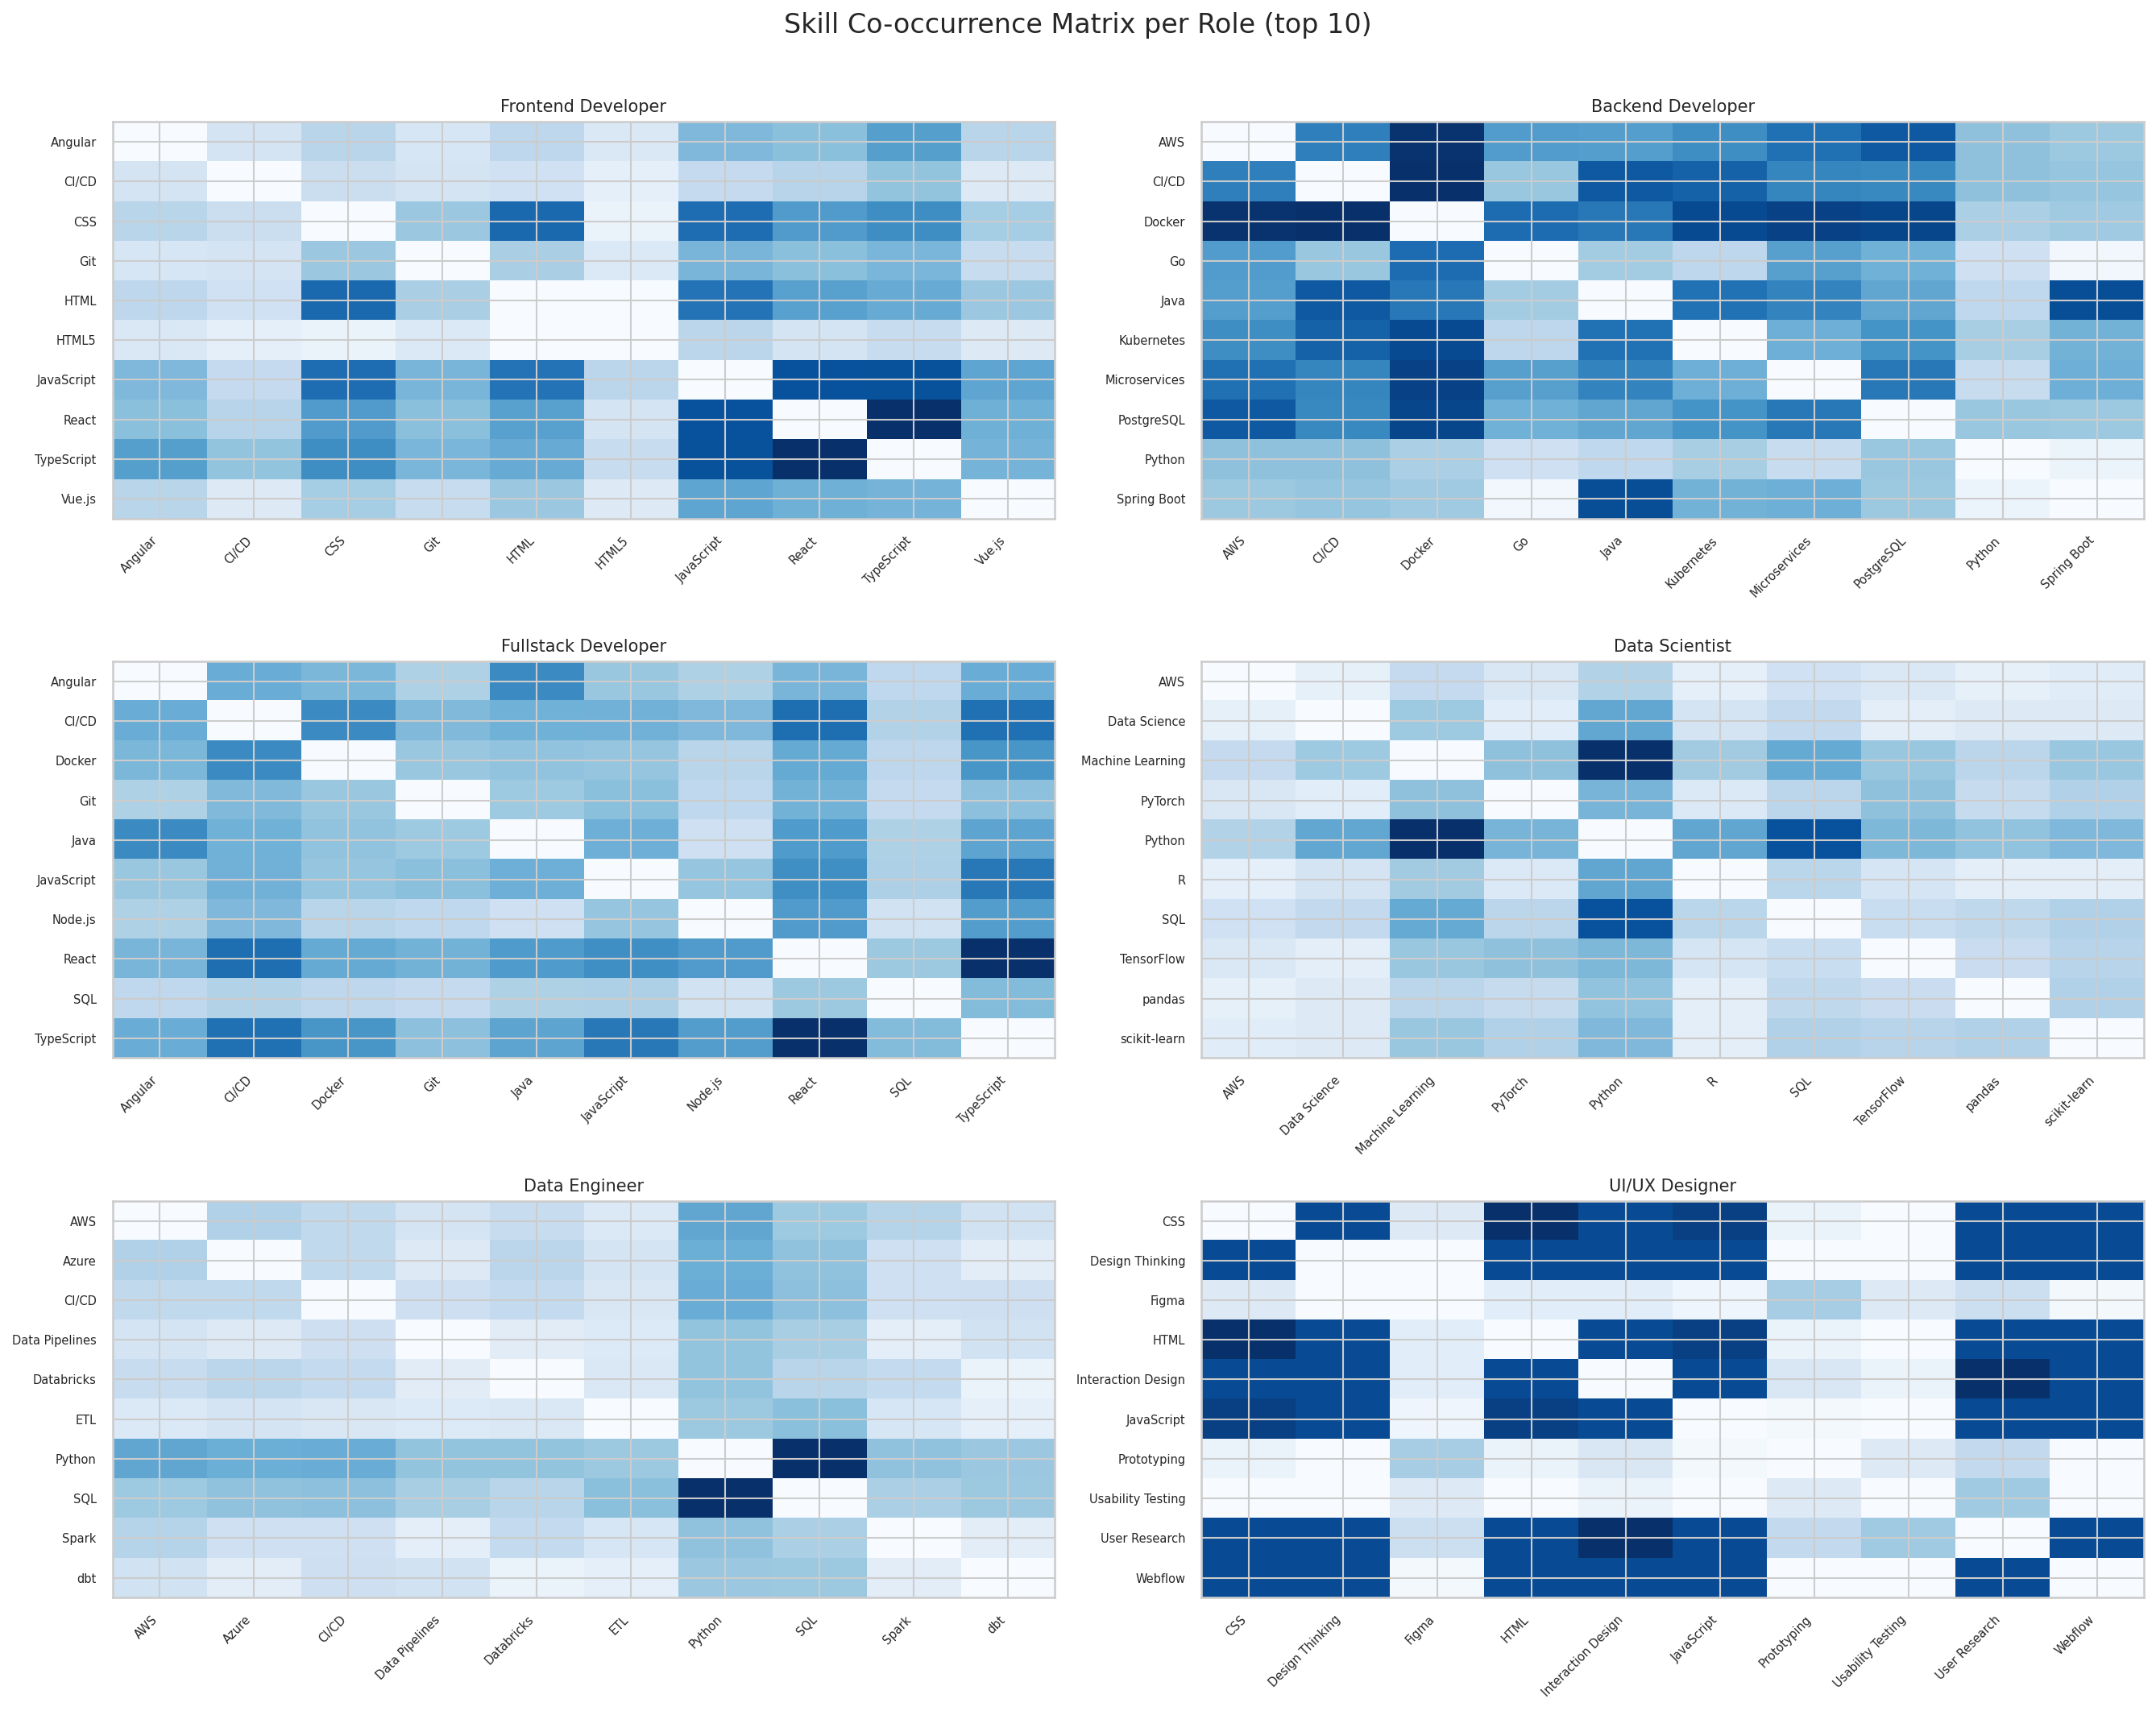

In [7]:
fig, axes = plt.subplots(rows_grid, cols, figsize=(18, 14 * rows_grid / 3))
fig.suptitle("Skill Co-occurrence Matrix per Role (top 10)", fontsize=16, y=1.01)

for ax, name in zip(axes.flat, TARGET_ROLES):
    rdf = roles[name]
    cooc = skill_cooccurrence(rdf, top_n=10)
    im = ax.imshow(cooc.values, aspect="auto", cmap="Blues")
    ax.set_xticks(range(len(cooc.columns)))
    ax.set_xticklabels(cooc.columns, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(cooc.index)))
    ax.set_yticklabels(cooc.index, fontsize=7)
    ax.set_title(f"{name}", fontsize=10)

for ax in axes.flat[n_roles:]:
    ax.set_visible(False)

plt.tight_layout()
if _charts.FIGURES_DIR:
    fig.savefig(_charts.FIGURES_DIR / "10_skill_cooccurrence_by_role.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

**Takeaway:** Frontend shows a tight TypeScript-React-JavaScript-CSS cluster. Fullstack mirrors this but adds Node.js and PostgreSQL into the core. Data Scientist has a strong Python-ML-SQL triangle. Backend is the most fragmented — Docker, Java, CI/CD, and AWS form a DevOps-flavoured cluster alongside a separate Python-PostgreSQL cluster.

## Skill Transferability Matrix

Jaccard similarity of each role pair's top-25 skill sets. Higher values mean more skill overlap and potentially easier career transitions.

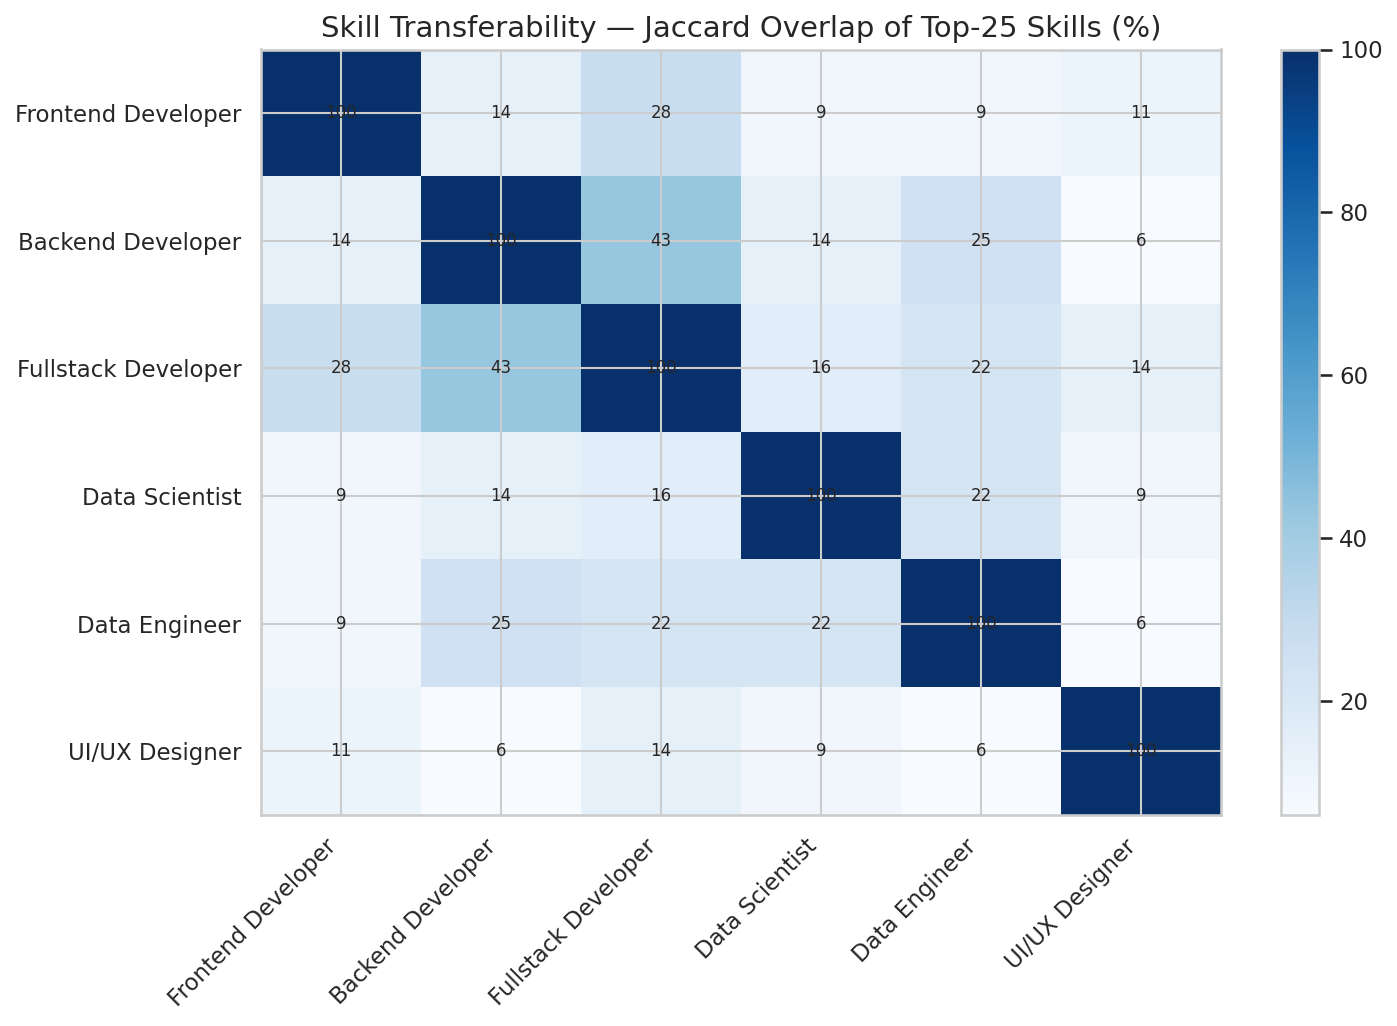

In [8]:
overlap = skill_overlap_matrix(roles, top_n=25)

heatmap(
    overlap.round(0),
    "Skill Transferability — Jaccard Overlap of Top-25 Skills (%)",
    figsize=(10, 7),
    save_as="10_skill_transferability.png",
)

**Takeaway:** Frontend ↔ Fullstack (highest overlap) is the easiest lateral move — most frontend skills transfer directly. Backend ↔ Fullstack is similarly close. Data Scientist ↔ Data Engineer share moderate overlap through Python/SQL/AWS. UI/UX Designer has very low overlap with all engineering roles, confirming it requires a fundamentally different skill set.

## Salary Analysis

> **Caution:** Only postings with explicit salary ranges are included. Data Scientist (n=5), Data Engineer (n=5), and UI/UX Designer (n=0) have too few salary rows for reliable statistics. Frontend (n=18) and Backend (n=27) are also thin. Only Fullstack Developer (n=74) approaches a reasonable sample size.

In [9]:
sal_rows = []
for name in TARGET_ROLES:
    sdf = salary_by_role[name]
    if len(sdf) == 0:
        sal_rows.append({"Role": name, "n": 0, "Median": None, "P25": None, "P75": None, "Min": None, "Max": None})
        continue
    sal_rows.append({
        "Role": name,
        "n": len(sdf),
        "Median": int(sdf["salary_mid"].median()),
        "P25": int(sdf["salary_mid"].quantile(0.25)),
        "P75": int(sdf["salary_mid"].quantile(0.75)),
        "Min": int(sdf["salary_mid"].min()),
        "Max": int(sdf["salary_mid"].max()),
    })

sal_summary = pd.DataFrame(sal_rows).set_index("Role")
print("Salary overview (EUR, annual) — interpret n < 15 with caution")
sal_summary

Salary overview (EUR, annual) — interpret n < 15 with caution


,n,Median,P25,P75,Min,Max
Role,,,,,,
Frontend Developer,18,58750.0,57500.0,86875.0,47500.0,110000.0
Backend Developer,26,76750.0,57500.0,95000.0,45000.0,117500.0
Fullstack Developer,72,68750.0,65000.0,77500.0,40000.0,120000.0
Data Scientist,5,75000.0,67500.0,77500.0,66704.0,92500.0
Data Engineer,5,83000.0,77500.0,95000.0,60000.0,120000.0
UI/UX Designer,0,NaN,NaN,NaN,NaN,NaN


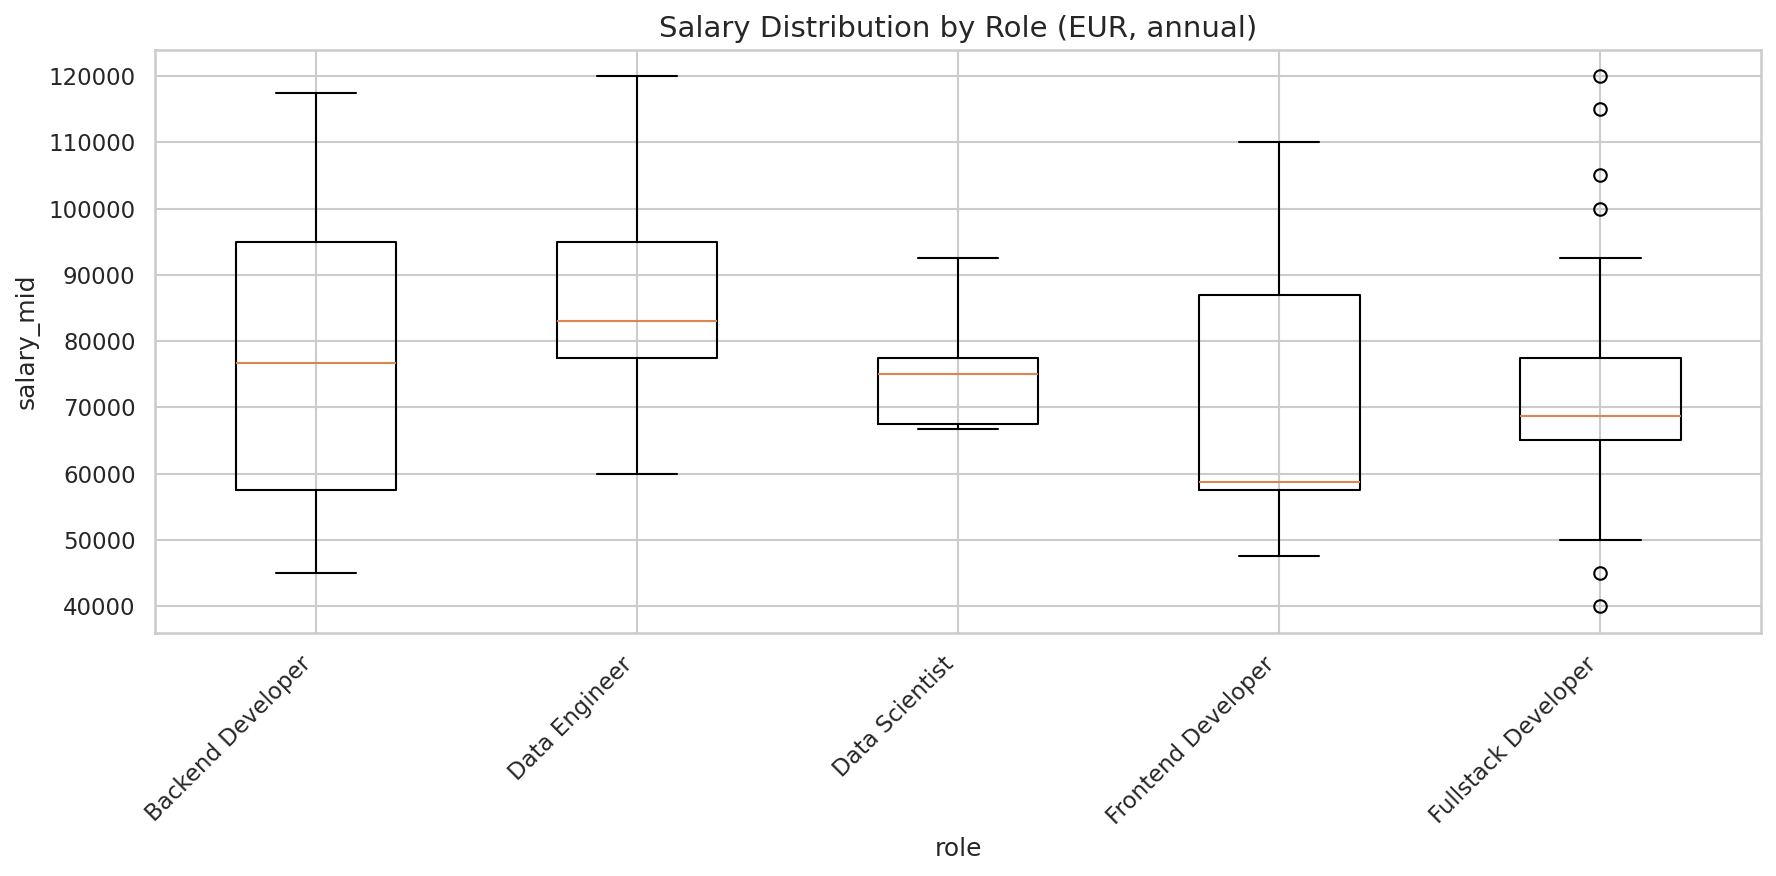

In [10]:
# Box plot for roles with enough salary data (n >= 3)
sal_roles = pd.concat(
    [salary_by_role[n].assign(role=n) for n in TARGET_ROLES if len(salary_by_role[n]) >= 3],
    ignore_index=True
)

if len(sal_roles) > 0:
    box_plot(
        sal_roles, x="role", y="salary_mid",
        title="Salary Distribution by Role (EUR, annual)",
        figsize=(12, 6),
        save_as="10_salary_by_role.png",
    )
else:
    print("Not enough salary data for box plot.")

## Skill-Salary Premium

Which skills are associated with higher-paying postings? Only postings with salary data are included.

> **Combined chart** uses min_count=10 (a skill must appear in at least 10 salary-known postings). **Per-role charts** use min_count=5 and are only shown for roles with ≥15 salary rows.

Salary-known rows across 6 target roles: 126


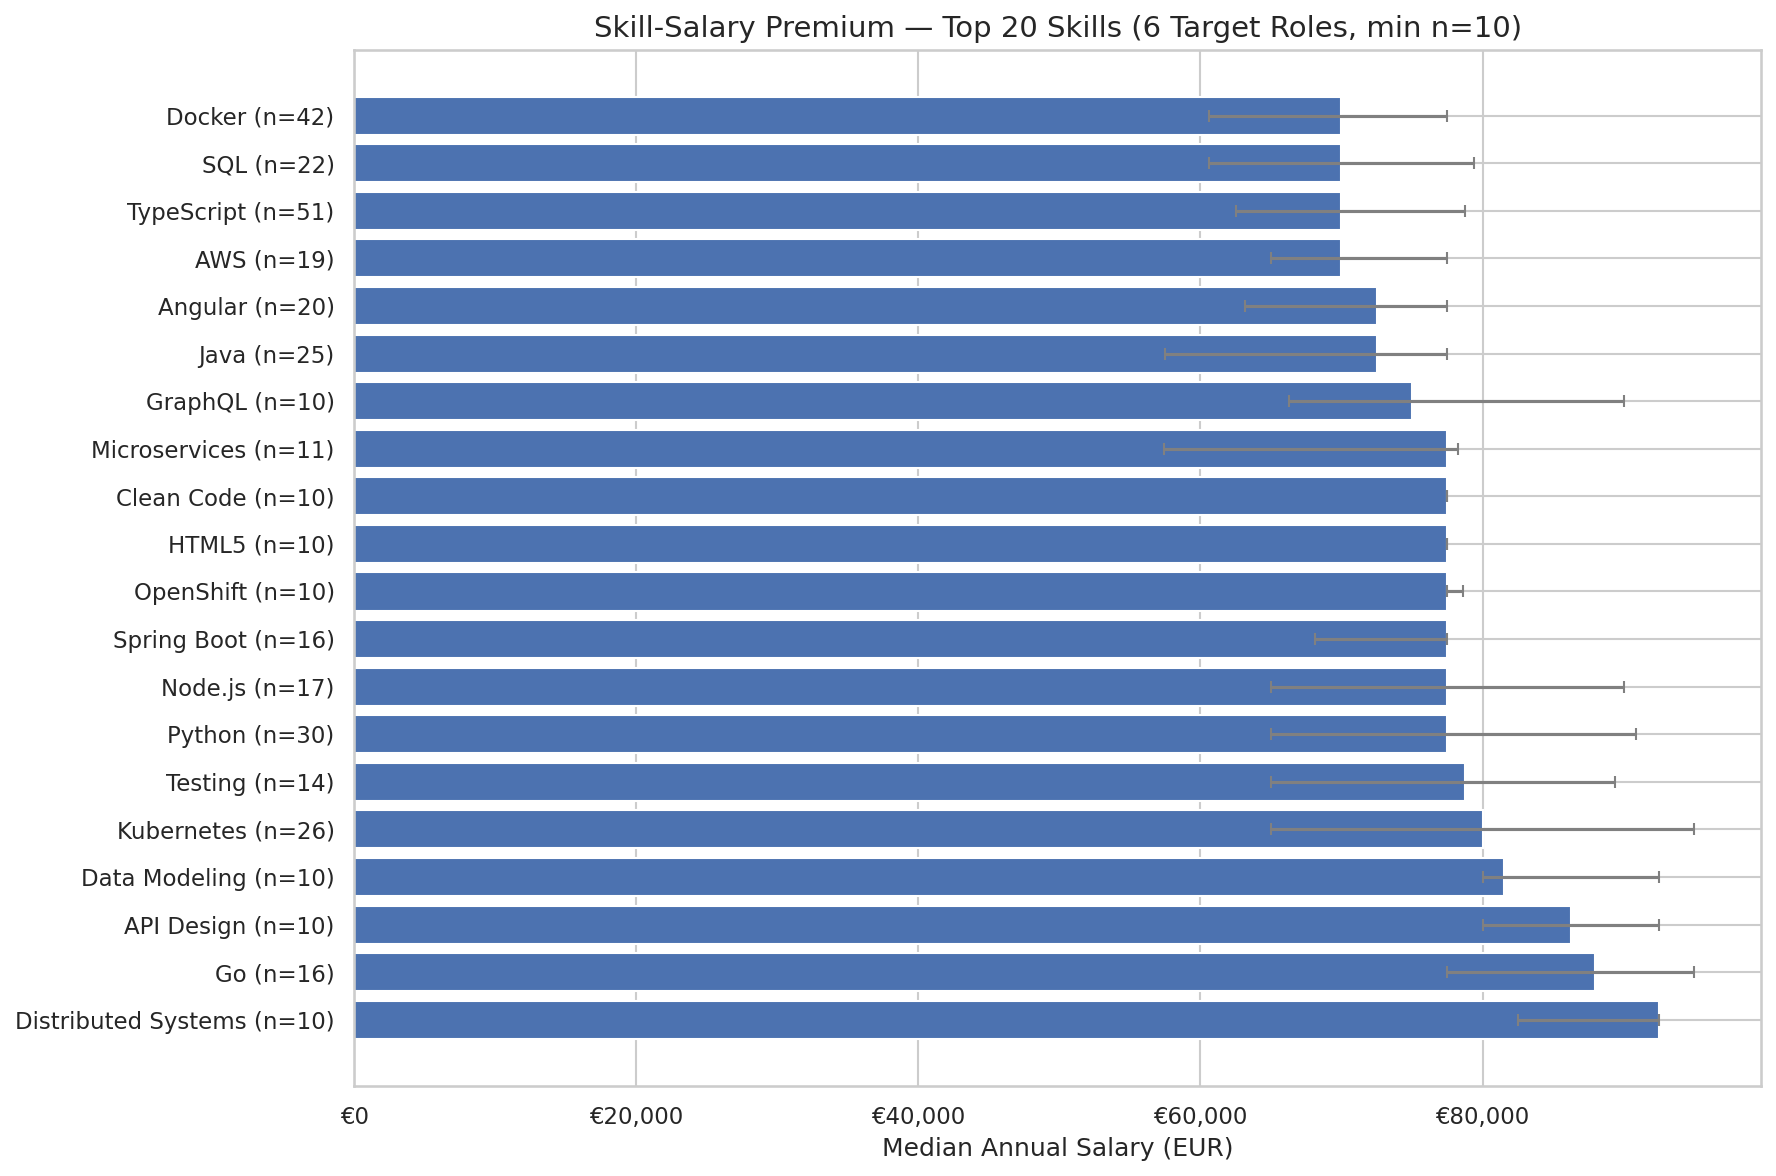

In [11]:
target_df = df[df["job_family"].isin(TARGET_ROLES)]
sdf_target = salary_df(target_df)
print(f"Salary-known rows across 6 target roles: {len(sdf_target)}")

if len(sdf_target) >= 20:
    premium = skill_salary_premium(sdf_target, min_count=10, top_n=20)

    if len(premium) > 0:
        fig, ax = plt.subplots(figsize=(12, 8))
        y_pos = range(len(premium))
        ax.barh(y_pos, premium["median"], color="#4C72B0")
        ax.errorbar(
            premium["median"], y_pos,
            xerr=[premium["median"] - premium["p25"], premium["p75"] - premium["median"]],
            fmt="none", ecolor="gray", capsize=3
        )
        ax.set_yticks(y_pos)
        ax.set_yticklabels([f"{s} (n={int(c)})" for s, c in zip(premium.index, premium["count"])])
        ax.set_xlabel("Median Annual Salary (EUR)")
        ax.set_title("Skill-Salary Premium — Top 20 Skills (6 Target Roles, min n=10)")
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
        plt.tight_layout()
        if _charts.FIGURES_DIR:
            fig.savefig(_charts.FIGURES_DIR / "10_skill_salary_premium.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close(fig)
    else:
        print("No skills meet min_count=10 threshold.")
else:
    print("Not enough salary data for combined skill-salary analysis.")

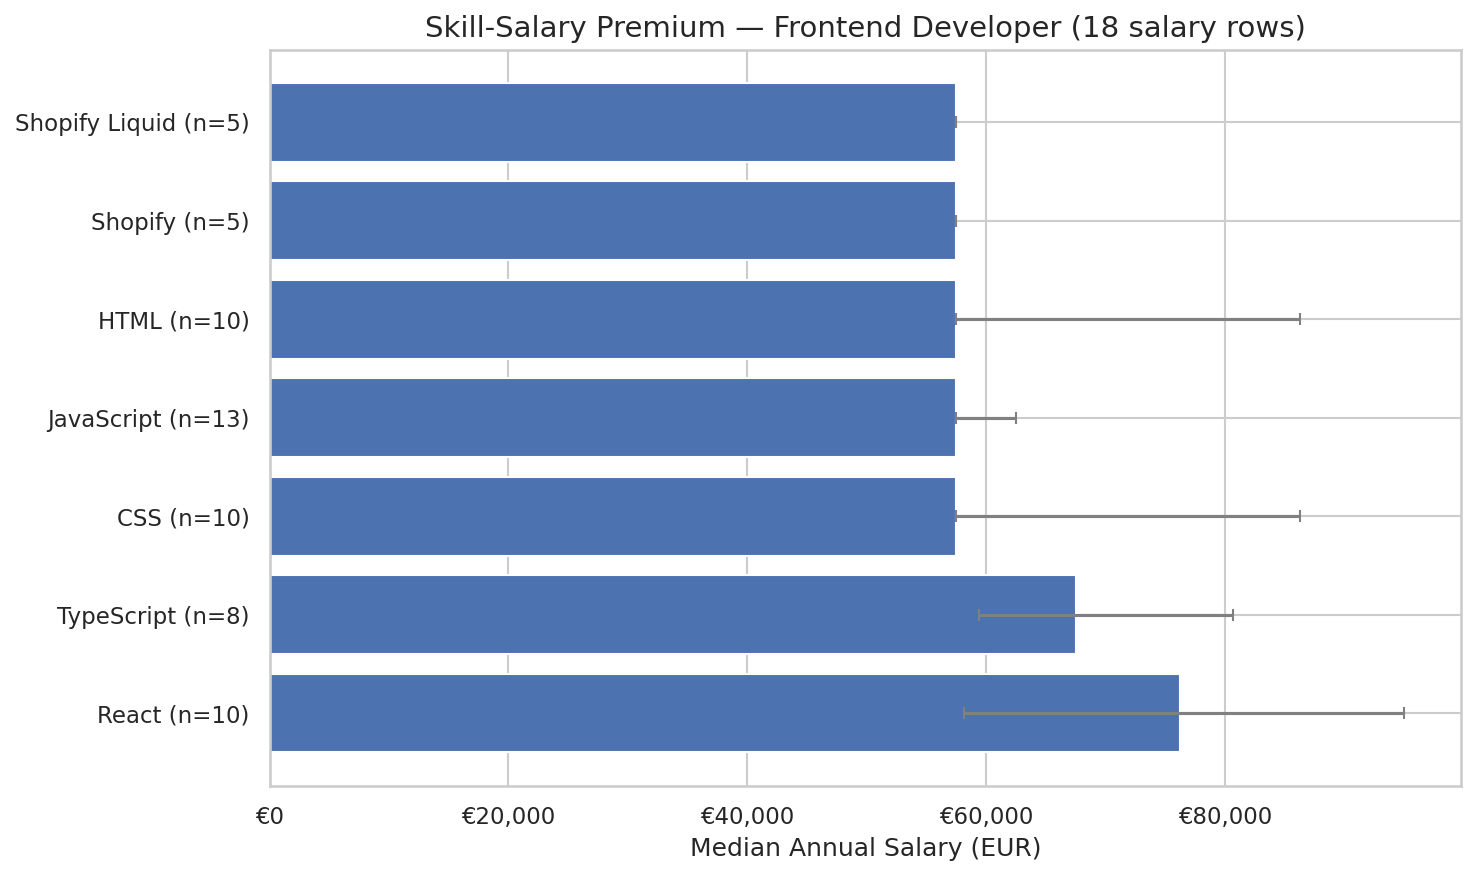

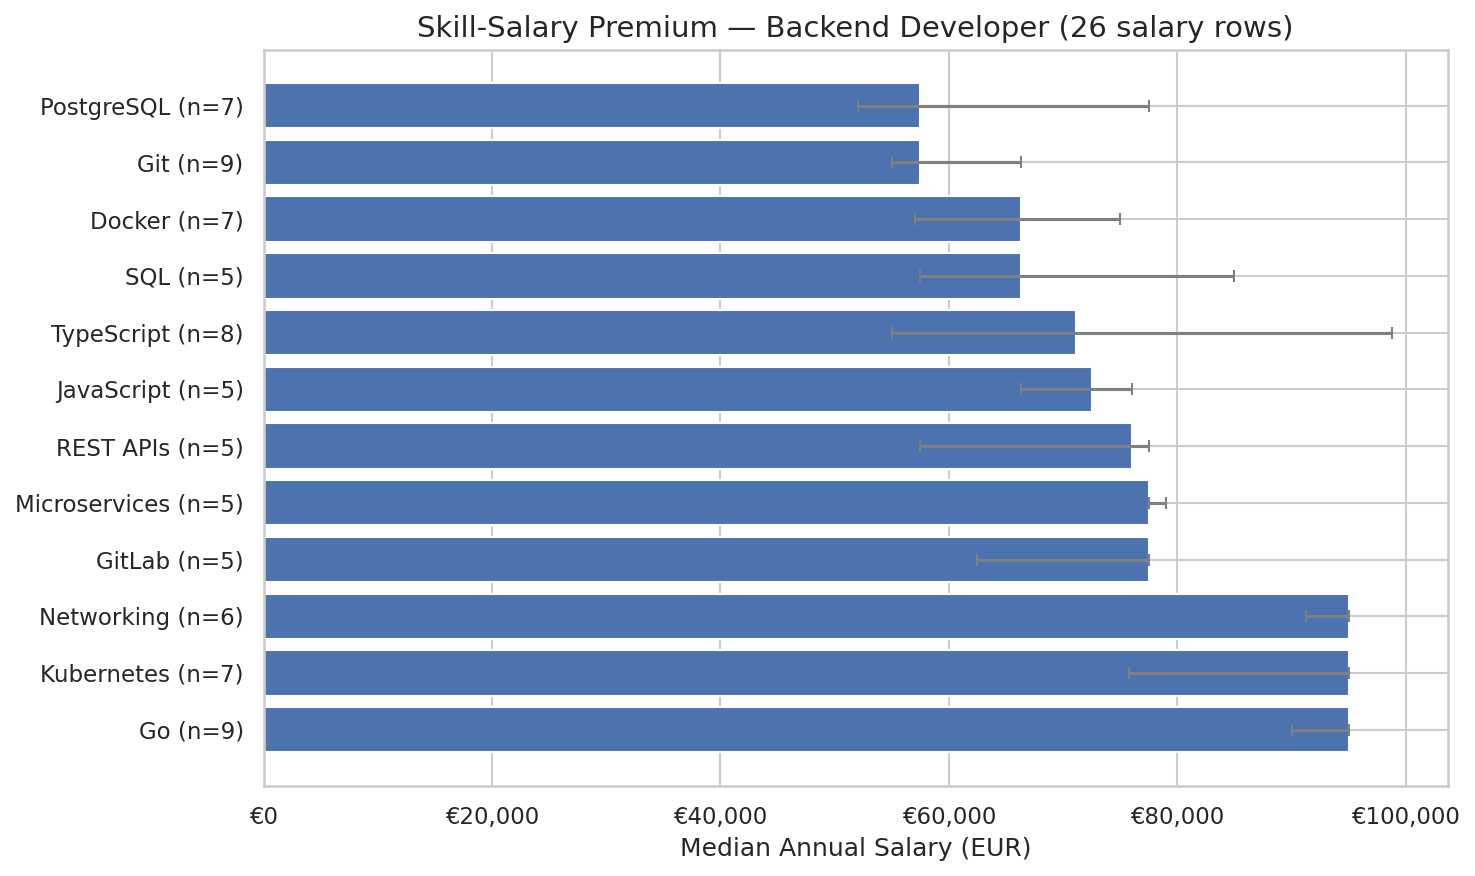

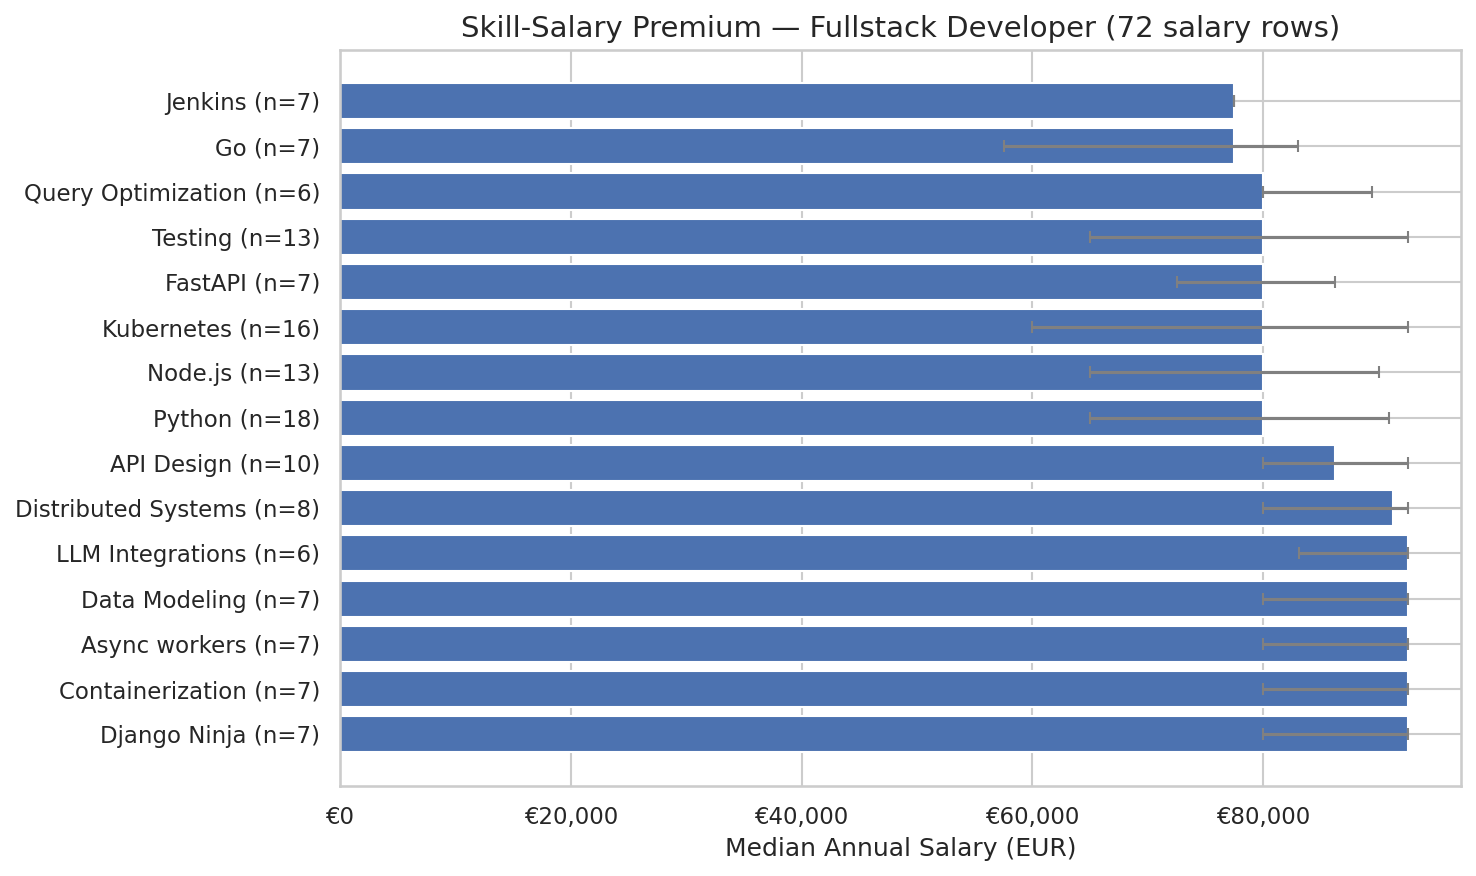

Data Scientist: only 5 salary rows — skipping (need 10+)
Data Engineer: only 5 salary rows — skipping (need 10+)
UI/UX Designer: only 0 salary rows — skipping (need 10+)


In [12]:
# Per-role skill-salary premium — only for roles with >= 10 salary rows
MIN_SALARY_ROWS = 10

for name in TARGET_ROLES:
    sdf_role = salary_by_role[name]
    if len(sdf_role) < MIN_SALARY_ROWS:
        print(f"{name}: only {len(sdf_role)} salary rows — skipping (need {MIN_SALARY_ROWS}+)")
        continue

    premium = skill_salary_premium(sdf_role, min_count=5, top_n=15)
    if len(premium) == 0:
        print(f"{name}: no skills meet min_count=5 — skipping")
        continue

    fig, ax = plt.subplots(figsize=(10, 6))
    y_pos = range(len(premium))
    ax.barh(y_pos, premium["median"], color="#4C72B0")
    ax.errorbar(
        premium["median"], y_pos,
        xerr=[premium["median"] - premium["p25"], premium["p75"] - premium["median"]],
        fmt="none", ecolor="gray", capsize=3
    )
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f"{s} (n={int(c)})" for s, c in zip(premium.index, premium["count"])])
    ax.set_xlabel("Median Annual Salary (EUR)")
    ax.set_title(f"Skill-Salary Premium — {name} ({len(sdf_role)} salary rows)")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
    plt.tight_layout()
    if _charts.FIGURES_DIR:
        fig.savefig(_charts.FIGURES_DIR / f"10_skill_salary_{name.lower().replace('/', '_').replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

**Takeaway:** With the raised min_count thresholds, the salary premium chart now only shows skills with enough data to be directionally meaningful. Infrastructure and DevOps skills (Docker, Kubernetes, AWS) consistently correlate with higher salaries across roles. Per-role charts are limited to Fullstack Developer (the only role with sufficient salary data for reliable per-skill analysis).

## Role Demographics

Education level, seniority, work modality, contract type, and language requirements across the six target roles — condensed into compact heatmaps.

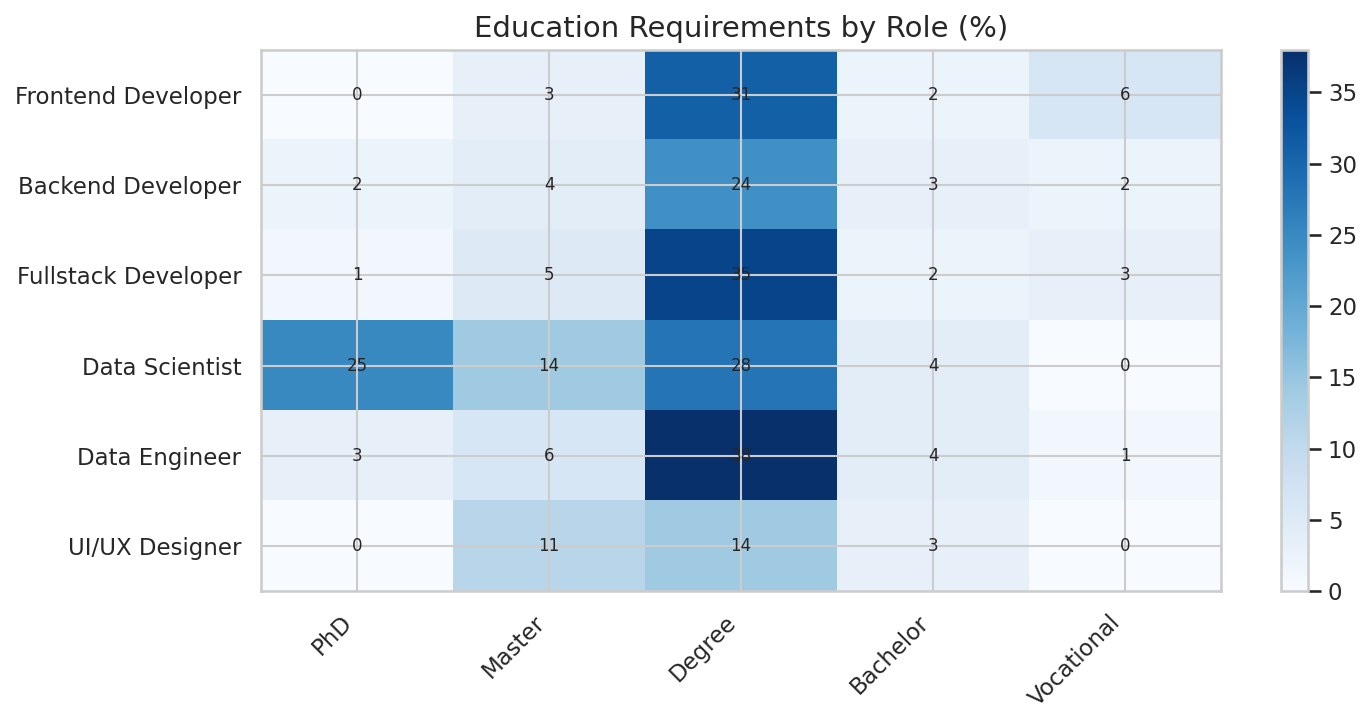

In [13]:
# Education
edu_df = categorical_distribution(
    roles, "education_level",
    ["PhD", "Master", "Degree", "Bachelor", "Vocational"],
)

heatmap(
    edu_df[["PhD", "Master", "Degree", "Bachelor", "Vocational"]].round(0),
    "Education Requirements by Role (%)",
    figsize=(10, 5),
    save_as="10_education_by_role.png",
)

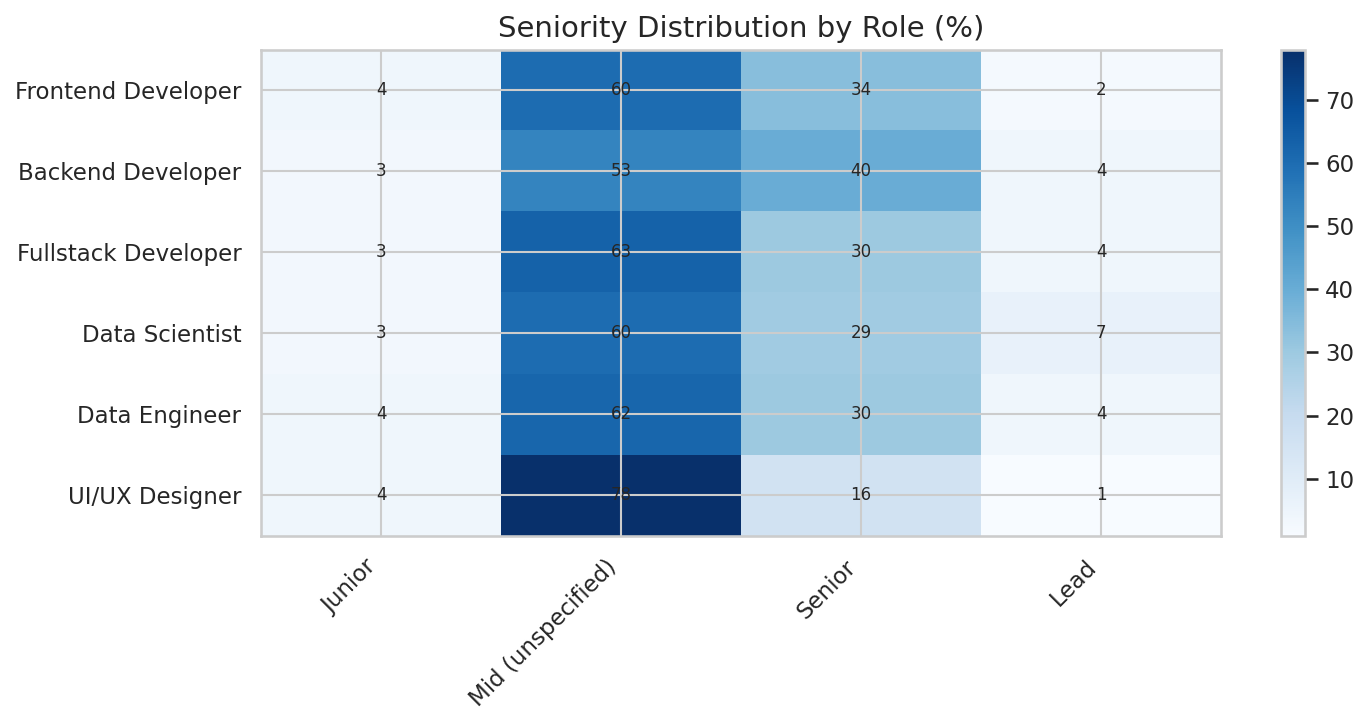

In [14]:
# Seniority
sen_df = categorical_distribution(
    roles, "seniority_from_title",
    ["Junior", "Senior", "Lead", "Director", "C-Level"],
)
# Rename 'Unspecified' to 'Mid (unspecified)' since NaN seniority is treated as mid-level
sen_df = sen_df.rename(columns={"Unspecified": "Mid (unspecified)"})

heatmap(
    sen_df[["Junior", "Mid (unspecified)", "Senior", "Lead"]].round(0),
    "Seniority Distribution by Role (%)",
    figsize=(10, 5),
    save_as="10_seniority_by_role.png",
)

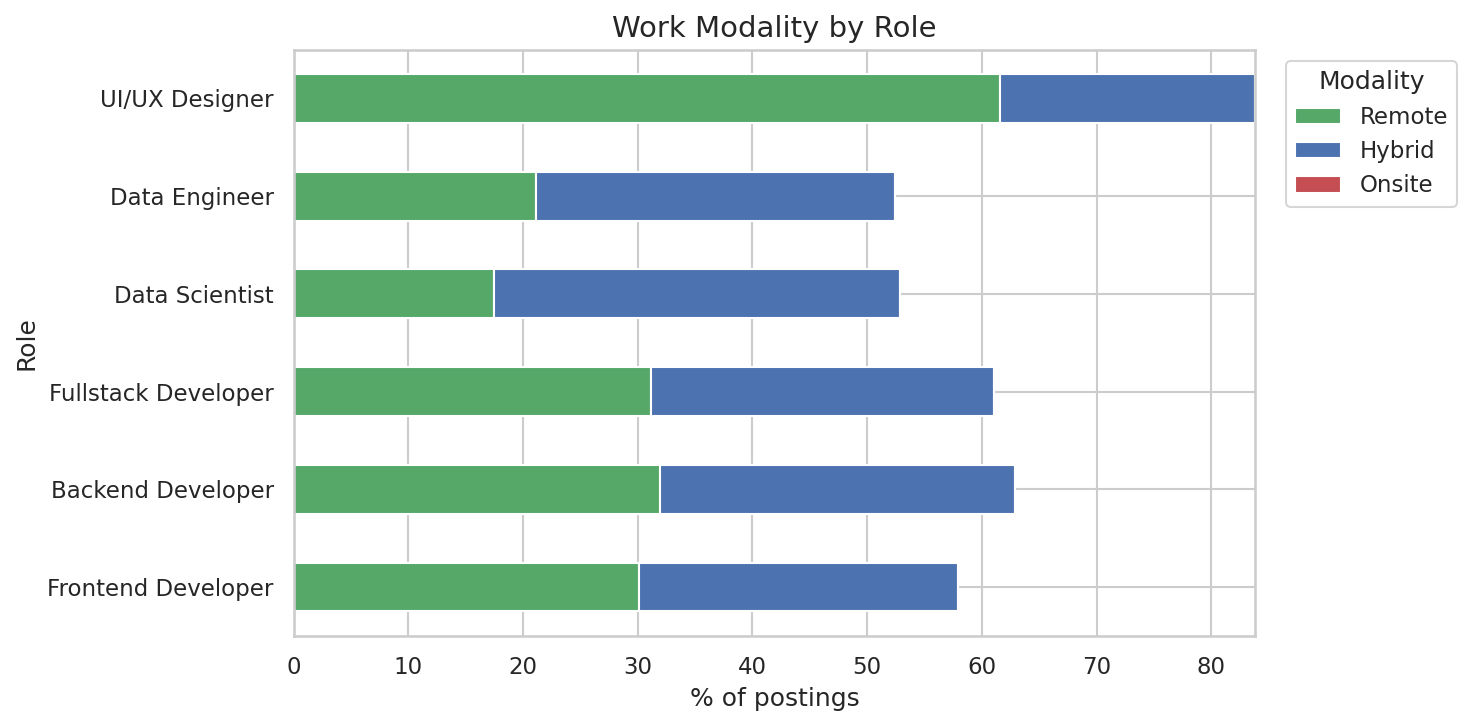

In [15]:
# Work modality
mod_df = categorical_distribution(
    roles, "work_modality",
    ["Remote", "Hybrid", "Onsite"],
    include_unspecified=False,
)

fig, ax = plt.subplots(figsize=(10, 5))
mod_df.plot(kind="barh", stacked=True, ax=ax, color=["#55A868", "#4C72B0", "#C44E52"])
ax.set_xlabel("% of postings")
ax.set_title("Work Modality by Role")
ax.legend(title="Modality", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
if _charts.FIGURES_DIR:
    fig.savefig(_charts.FIGURES_DIR / "10_modality_by_role.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

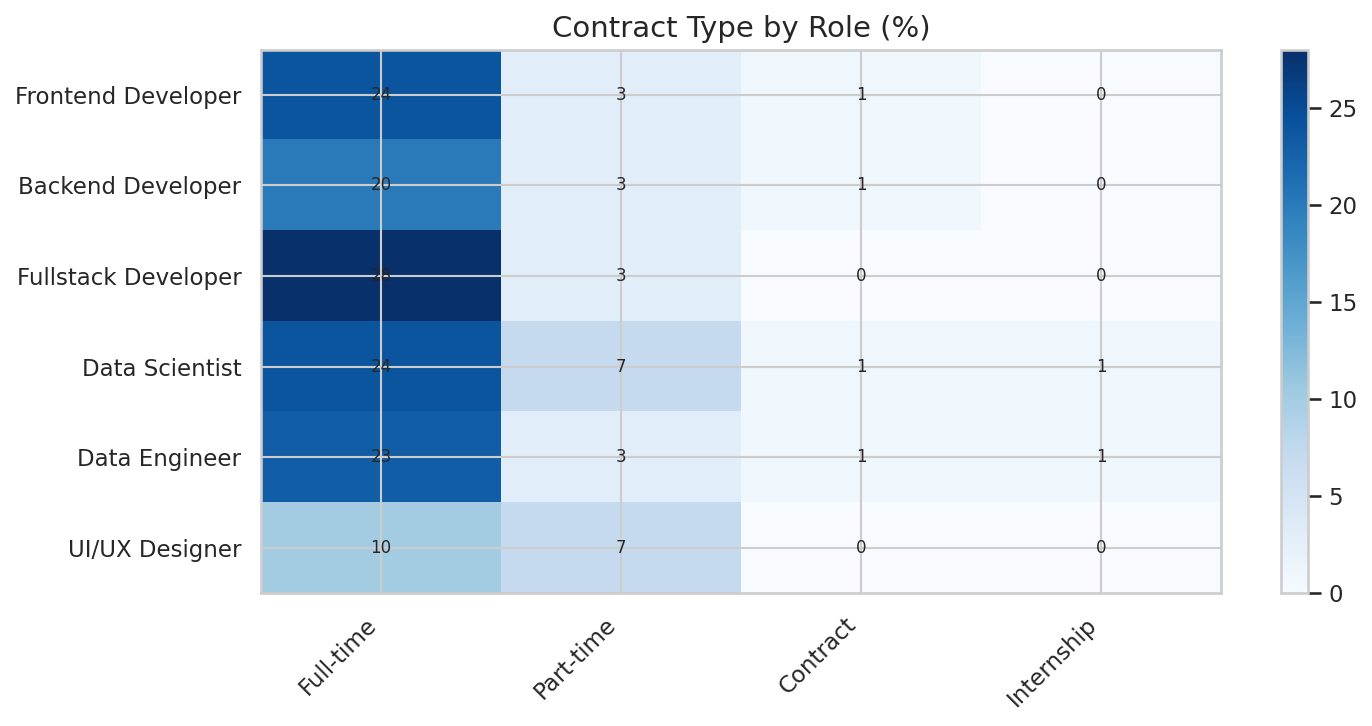

In [16]:
# Contract type
ct_df = categorical_distribution(
    roles, "contract_type",
    ["Full-time", "Part-time", "Contract", "Internship", "Temporary"],
)
ct_df = ct_df.loc[:, ct_df.sum() > 0]  # drop all-zero columns

heatmap(
    ct_df.drop(columns=["Unspecified"], errors="ignore").round(0),
    "Contract Type by Role (%)",
    figsize=(10, 5),
    save_as="10_contract_type_by_role.png",
)

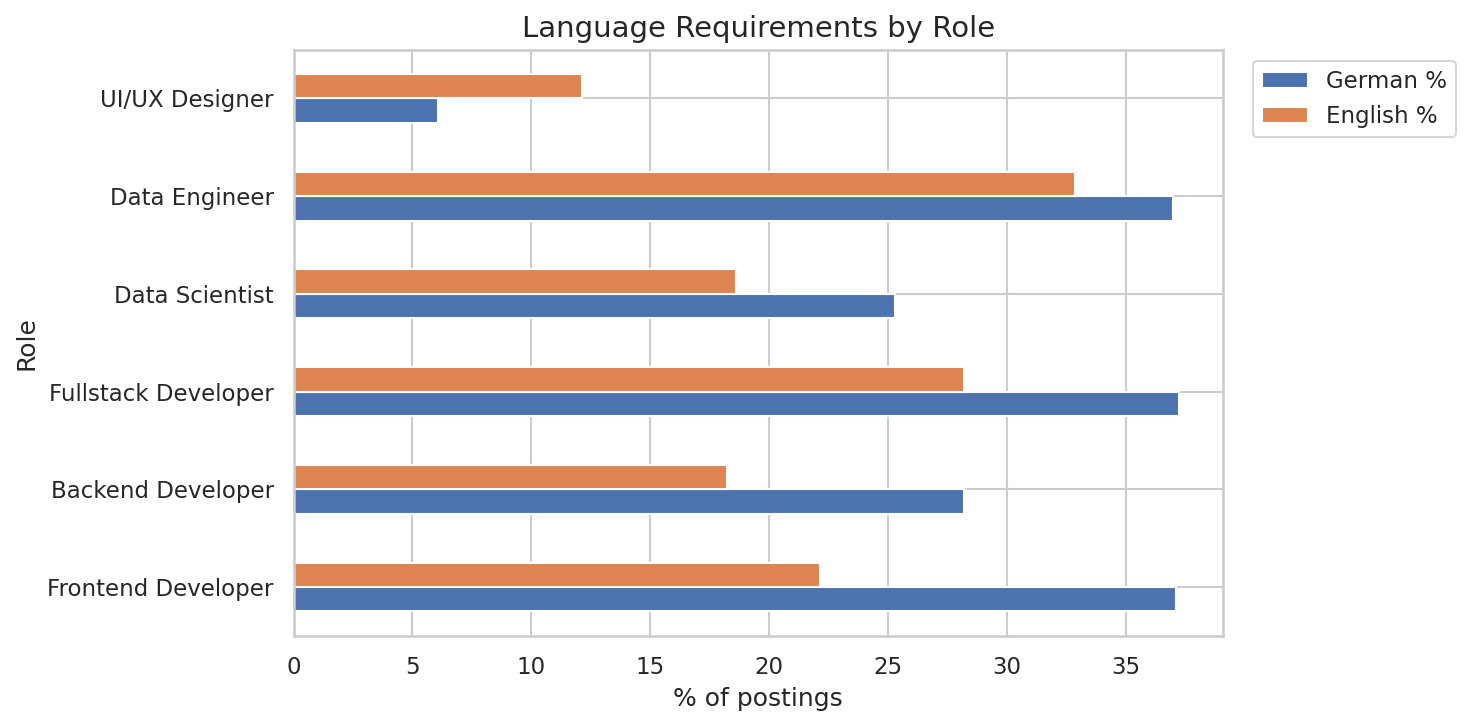

,German %,English %
Role,,
Frontend Developer,37.1,22.1
Backend Developer,28.2,18.2
Fullstack Developer,37.2,28.2
Data Scientist,25.3,18.6
Data Engineer,37.0,32.9
UI/UX Designer,6.1,12.1


In [17]:
# Language requirements
lang_df = language_requirement_pct(roles)

fig, ax = plt.subplots(figsize=(10, 5))
lang_df.plot(kind="barh", ax=ax)
ax.set_xlabel("% of postings")
ax.set_title("Language Requirements by Role")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
if _charts.FIGURES_DIR:
    fig.savefig(_charts.FIGURES_DIR / "10_languages_by_role.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

lang_df.round(1)

**Takeaway:** All six roles are overwhelmingly mid-level (seniority unspecified in 60-85% of postings). UI/UX Designer has the highest remote rate (61%) and the lowest German language requirement (6%) — the most internationally accessible role. Data roles (Scientist/Engineer) require German less often than web development roles, reflecting the English-first culture of data teams. Full-time contracts dominate across the board (>85%).

## Experience Requirements

In [18]:
exp_data = []
for name in TARGET_ROLES:
    rdf = roles[name]
    exp = pd.to_numeric(rdf["experience_years"], errors="coerce").dropna()
    if len(exp) == 0:
        exp_data.append({"Role": name, "n": 0, "Median": None, "P25": None, "P75": None})
        continue
    exp_data.append({
        "Role": name,
        "n": len(exp),
        "Median": exp.median(),
        "P25": exp.quantile(0.25),
        "P75": exp.quantile(0.75),
    })

exp_df = pd.DataFrame(exp_data).set_index("Role")
print("Experience requirements (years)")
print("Note: uniformity (median=3 across all roles) may reflect LLM extraction")
print("defaulting to \"3 years\" for vague phrasing like \"several years\".")
exp_df

Experience requirements (years)
Note: uniformity (median=3 across all roles) may reflect LLM extraction
defaulting to "3 years" for vague phrasing like "several years".


,n,Median,P25,P75
Role,,,,
Frontend Developer,143,3.0,3.0,5.00
Backend Developer,223,3.0,3.0,4.00
Fullstack Developer,528,3.0,3.0,4.25
Data Scientist,74,3.0,3.0,5.00
Data Engineer,229,3.0,3.0,3.00
UI/UX Designer,7,3.0,2.5,4.50


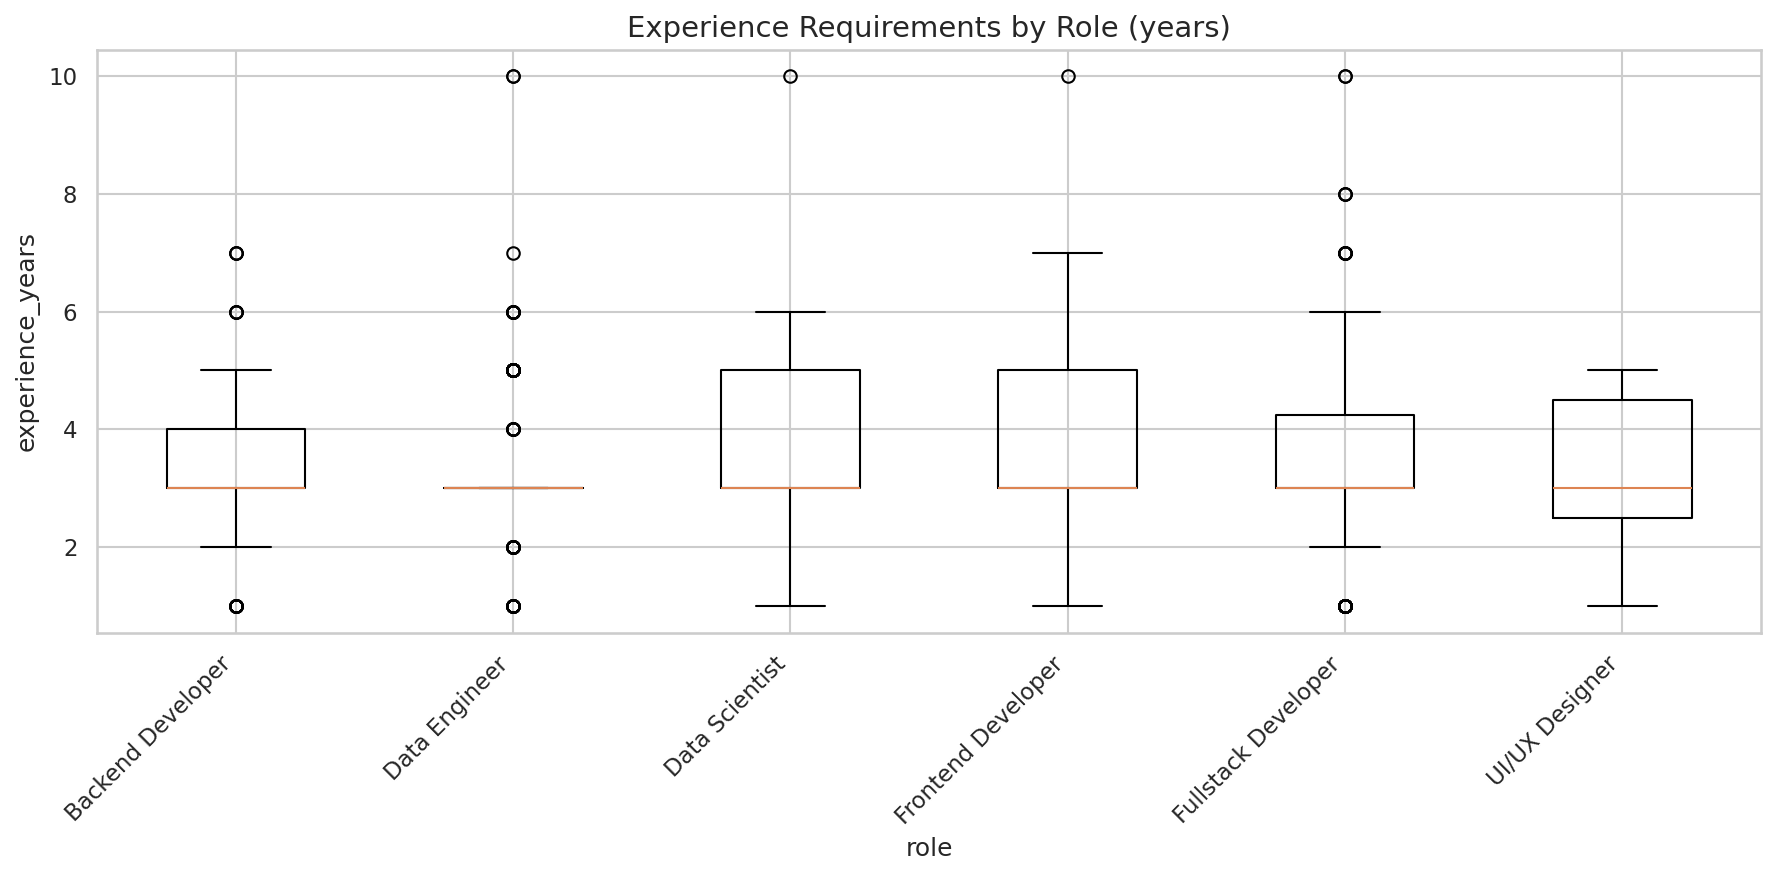

In [19]:
# Box plot for experience years
exp_roles = pd.concat(
    [roles[n].assign(
        experience_years=pd.to_numeric(roles[n]["experience_years"], errors="coerce")
    )[["experience_years"]].dropna().assign(role=n)
     for n in TARGET_ROLES
     if pd.to_numeric(roles[n]["experience_years"], errors="coerce").notna().sum() >= 5],
    ignore_index=True
)

if len(exp_roles) > 0:
    box_plot(
        exp_roles, x="role", y="experience_years",
        title="Experience Requirements by Role (years)",
        figsize=(12, 6),
        save_as="10_experience_by_role.png",
    )
else:
    print("Not enough experience data for box plot.")

**Takeaway:** All roles cluster around a 3-year median experience requirement with little differentiation. This uniformity is likely an artefact of how job postings phrase requirements and how the LLM extracts them. The P75 spread (3–5 years) offers slightly more signal — Frontend and Data Scientist trend higher at the top end.

## Top Cities per Role

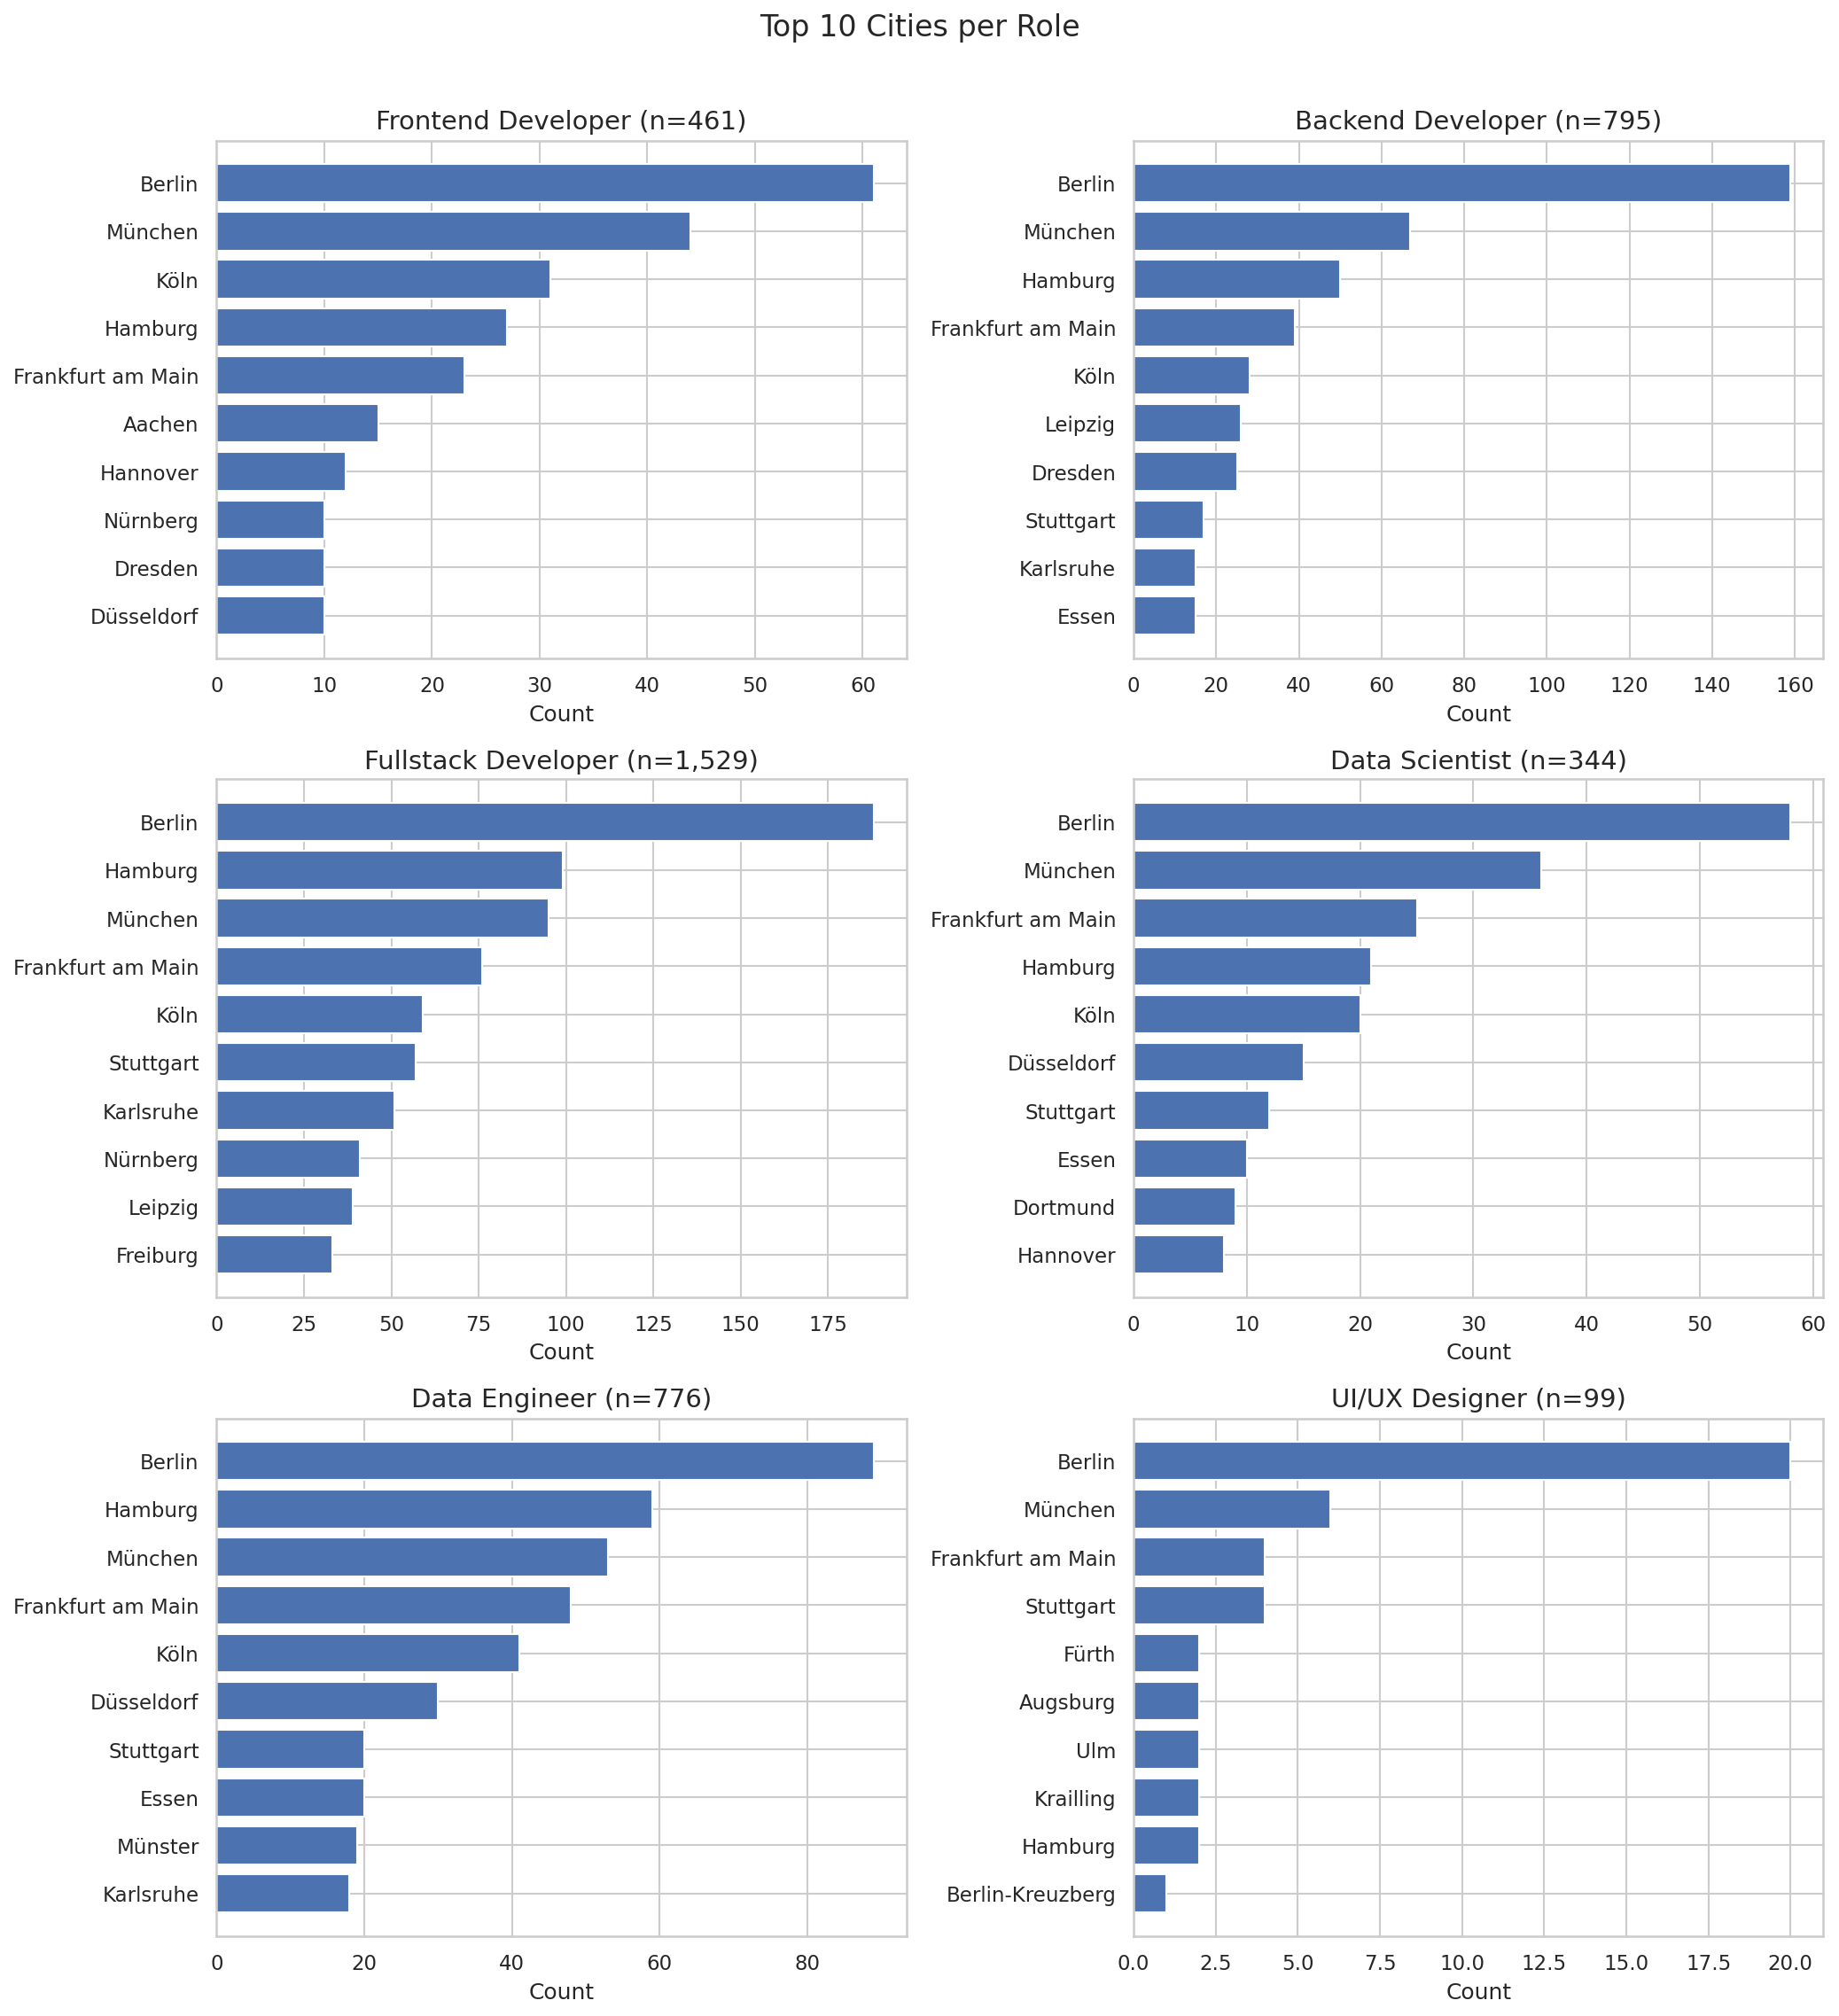

In [20]:
fig, axes = plt.subplots(rows_grid, cols, figsize=(14, 5 * rows_grid))
fig.suptitle("Top 10 Cities per Role", fontsize=16, y=1.01)

for ax, name in zip(axes.flat, TARGET_ROLES):
    rdf = roles[name]
    city_counts = rdf[rdf["city"].notna()]["city"].value_counts().head(10).sort_values()
    ax.barh(city_counts.index, city_counts.values)
    ax.set_title(f"{name} (n={len(rdf):,})")
    ax.set_xlabel("Count")

for ax in axes.flat[n_roles:]:
    ax.set_visible(False)

plt.tight_layout()
if _charts.FIGURES_DIR:
    fig.savefig(_charts.FIGURES_DIR / "10_cities_by_role.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

**Takeaway:** Berlin dominates all six roles, followed by München and Hamburg. Data Engineer shows the most geographic diversity (Frankfurt and Stuttgart rank higher than for other roles). UI/UX Designer is the most Berlin-concentrated — consistent with the startup and design-agency ecosystem there.

## Benefits & Soft Skills

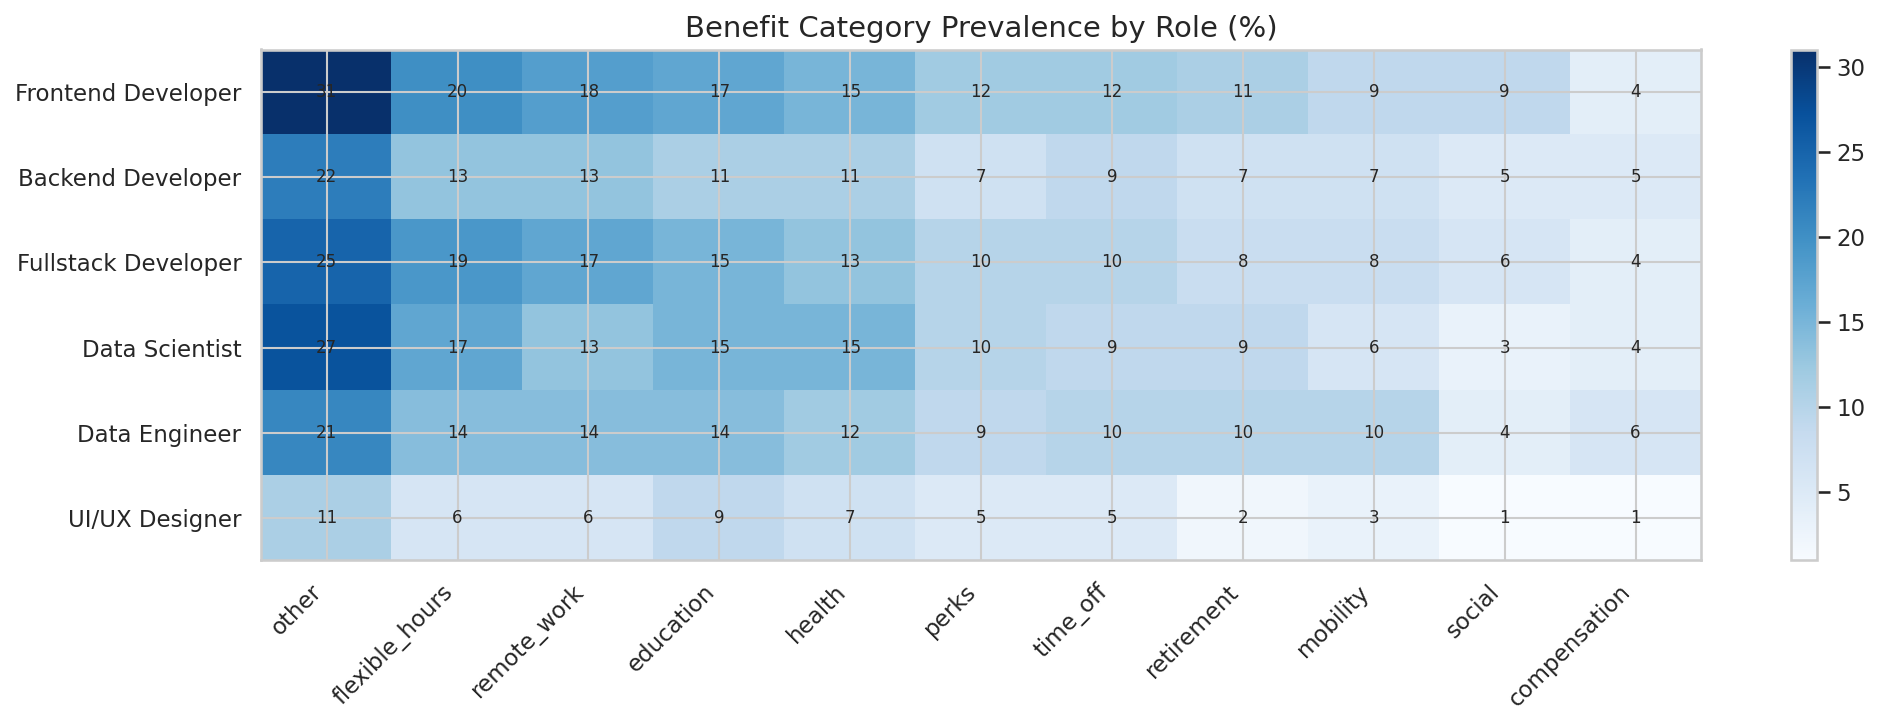

In [21]:
# Benefit categories
ben_data = []
for name in TARGET_ROLES:
    rdf = roles[name]
    total = max(1, len(rdf))
    cats = rdf["benefit_categories"].apply(parse_json_list)
    all_cats_flat = [c for lst in cats for c in lst if c]
    cat_counts = pd.Series(all_cats_flat).value_counts()
    row = {"Role": name}
    for cat in cat_counts.index:
        row[cat] = cats.apply(lambda lst, c=cat: c in lst).sum() / total * 100
    ben_data.append(row)

ben_df = pd.DataFrame(ben_data).set_index("Role").fillna(0)
ben_df = ben_df.loc[:, ben_df.max() > 5]
ben_df = ben_df[ben_df.mean().sort_values(ascending=False).index]

heatmap(
    ben_df.round(0),
    "Benefit Category Prevalence by Role (%)",
    figsize=(14, 5),
    fmt=".0f",
    save_as="10_benefits_by_role.png",
)

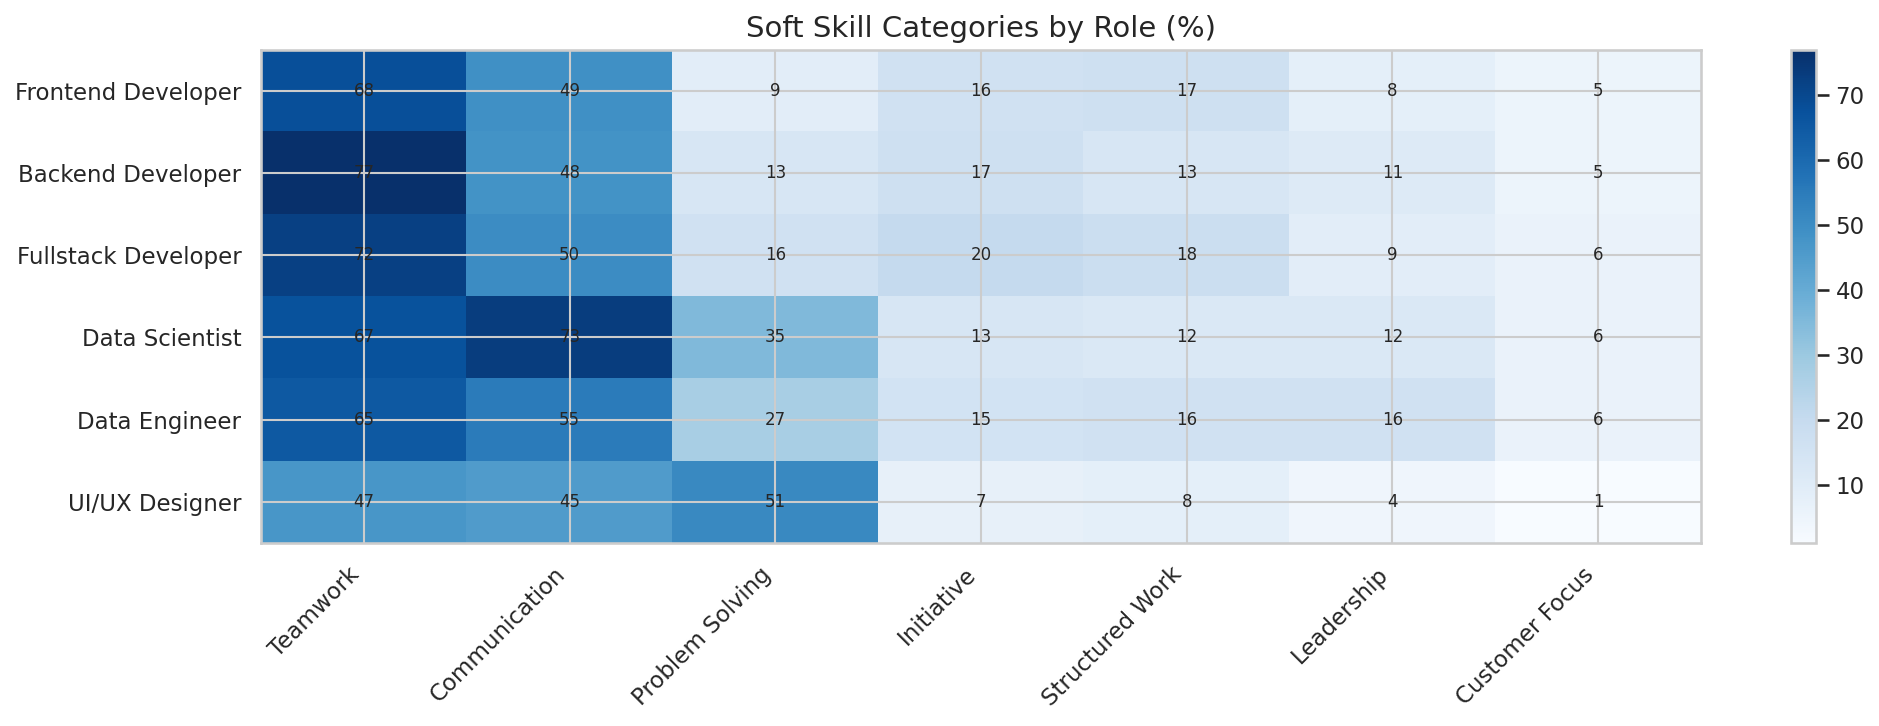

In [22]:
# Soft skill categories
ss_data = []
for name in TARGET_ROLES:
    rdf = roles[name]
    total = max(1, len(rdf))
    cats = rdf["soft_skill_categories"].apply(parse_json_list)
    all_cats_flat = [c for lst in cats for c in lst if c]
    cat_counts = pd.Series(all_cats_flat).value_counts()
    row = {"Role": name}
    for cat in cat_counts.index:
        row[cat] = cats.apply(lambda lst, c=cat: c in lst).sum() / total * 100
    ss_data.append(row)

ss_df = pd.DataFrame(ss_data).set_index("Role").fillna(0)
ss_df = ss_df.loc[:, ss_df.max() > 5]
ss_df = ss_df[ss_df.mean().sort_values(ascending=False).index]

heatmap(
    ss_df.round(0),
    "Soft Skill Categories by Role (%)",
    figsize=(14, 5),
    fmt=".0f",
    save_as="10_soft_skills_by_role.png",
)

**Takeaway:** Flexible hours and remote work are the most commonly listed benefits across all roles, but Frontend Developer leads in education/training benefits (17%). UI/UX Designer has the lowest benefit prevalence overall — likely reflecting the smaller companies (agencies, startups) that dominate its postings. Soft skills are remarkably uniform; Teamwork and Communication dominate everywhere, with UI/UX Designer showing slightly more emphasis on Creativity.